Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)
Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.
Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).
Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.
Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).


In [18]:
#Carregando bibliotecas
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.base import clone

RANDOM_STATE = 42

Carregando o MNIST:

In [19]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(int)

Verificando estrutura dos dados:



In [20]:
print("X:", X.shape)
print("y:", y.shape)
print("Pixel mínimo:", X.min())
print("Pixel máximo:", X.max())

X: (70000, 784)
y: (70000,)
Pixel mínimo: 0
Pixel máximo: 255


Dimensionalidade dos dados

Foi confirmado que `X` possui shape `(70000, 784)` — 70 mil imagens,
cada uma "achatada" de 28x28 pixels em um vetor de 784 valores — e que
`y` possui shape `(70000,)`, um rótulo por imagem.

Verificando a quantidade de imagens de cada dígito:

In [21]:
distribuicao = (
    pd.Series(y)
    .value_counts()
    .sort_index()
)

display(
    pd.DataFrame({
        "Dígito": distribuicao.index,
        "Quantidade": distribuicao.values
    })
)

,Dígito,Quantidade
0,0,6903
1,1,7877
2,2,6990
3,3,7141
4,4,6824
5,5,6313
6,6,6876
7,7,7293
8,8,6825
9,9,6958


Antes de treinar qualquer modelo, é importante confirmar que as classes(dígitos 0 a 9) estão razoavelmente balanceadas. Isso justifica o uso da
acurácia como métrica confiável mais adiante — em um dataset desbalanceado, a acurácia pode enganar (um modelo que só "chuta" a classe majoritária
teria acurácia alta sem aprender nada).

In [22]:
classes, contagens = np.unique(y, return_counts=True)
for c, n in zip(classes, contagens):
    print(f"Dígito {c}: {n} amostras")

Dígito 0: 6903 amostras
Dígito 1: 7877 amostras
Dígito 2: 6990 amostras
Dígito 3: 7141 amostras
Dígito 4: 6824 amostras
Dígito 5: 6313 amostras
Dígito 6: 6876 amostras
Dígito 7: 7293 amostras
Dígito 8: 6825 amostras
Dígito 9: 6958 amostras


Gráfico de distribuição das classes:

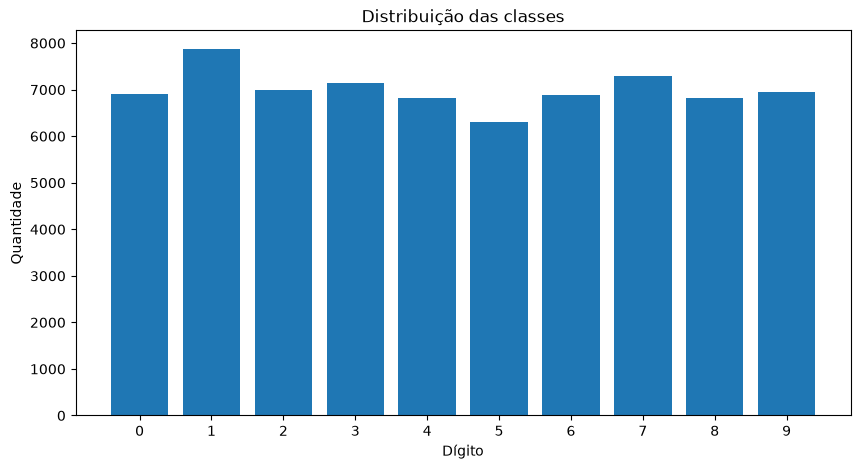

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    distribuicao.index.astype(str),
    distribuicao.values
)

plt.xlabel("Dígito")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes")

plt.show()

Mostra um exemplo de cada classe:

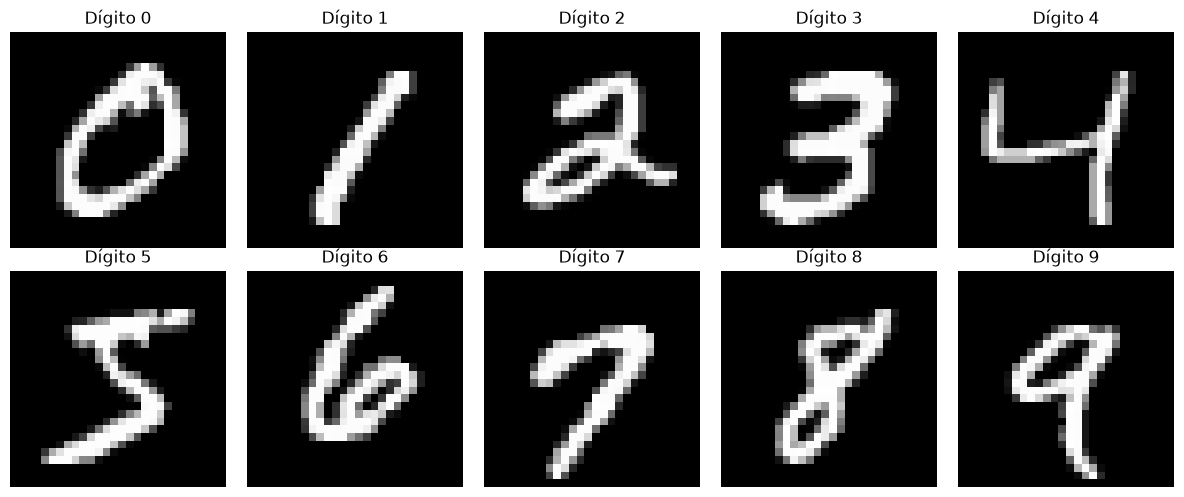

In [24]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for digito in range(10):

    indice = np.where(
        y == digito
    )[0][0]

    imagem = X[indice].reshape(
        28,
        28
    )

    axes.flat[digito].imshow(
        imagem,
        cmap="gray"
    )

    axes.flat[digito].set_title(
        f"Dígito {digito}"
    )

    axes.flat[digito].axis(
        "off"
    )

plt.tight_layout()
plt.show()

Justificativa da Fase 1: o objetivo é conhecer a estrutura do dataset, verificar as classes, visualizar exemplos e confirmar que os pixels variam de 0 a 255. O trabalho pede exatamente dimensões, distribuição das classes, exemplos visuais e a explicação de 28×28 → 784.

## Estrutura dos dados do MNIST

O conjunto de dados **MNIST** é composto por imagens de dígitos manuscritos, representando os números de **0 a 9**. Cada imagem possui dimensões de **28 × 28 pixels** e está em escala de cinza.

### Intensidade dos pixels

Cada pixel da imagem é representado por um valor numérico entre **0 e 255**, indicando sua intensidade:

- **0** → pixel preto;
- **255** → pixel branco;
- **Valores intermediários** → diferentes tons de cinza.

Dessa forma, quanto maior o valor do pixel, mais clara é aquela região da imagem.

### Representação 28 × 28

Originalmente, cada imagem pode ser representada como uma matriz de **28 linhas por 28 colunas**:

**28 × 28 = 784 pixels**

Cada posição dessa matriz corresponde a um pixel da imagem e contém um valor entre 0 e 255.

### Vetorização das imagens

Para utilizar as imagens em muitos algoritmos de Machine Learning, a matriz bidimensional de **28 × 28 pixels** pode ser transformada em um vetor unidimensional.

Assim, os 784 pixels são organizados sequencialmente:

**28 × 28 → 784 features**

Portanto, cada imagem passa a ser representada por **784 características (features)**, em que cada feature corresponde à intensidade de um determinado pixel.

Exemplo simplificado:

Imagem 28 × 28:

    [[0,   0,  25, ...],
     [0, 120, 255, ...],
     [0,  80, 200, ...],
     ...]

Após a vetorização:

    [0, 0, 25, ..., 0, 120, 255, ..., 0, 80, 200, ...]

Dessa maneira, cada linha do conjunto de dados representa **uma imagem**, enquanto as **784 colunas de entrada representam os pixels** dessa imagem.

A variável alvo (*target*) corresponde ao **dígito representado na imagem**, podendo assumir valores inteiros de **0 a 9**.

### Resumo da estrutura

| Característica | Descrição |
|---|---|
| Dimensão original | 28 × 28 pixels |
| Número total de pixels | 784 |
| Intensidade dos pixels | 0 a 255 |
| 0 | Preto |
| 255 | Branco |
| Entrada do modelo | 784 features |
| Classes | Dígitos de 0 a 9 |
| Número de classes | 10 |

Essa transformação permite que algoritmos que trabalham com dados tabulares recebam cada imagem como um conjunto de **784 variáveis numéricas**, preservando as informações de intensidade dos pixels.

Fase 2: Pipeline de Pré-processamento e Divisão dos Dados
Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), garantindo estratificação por classe (stratify=y).
Normalização / Escalonamento: Aplicar o redimensionamento dos pixels para a escala [0.0, 1.0] (dividindo por 255.0 ou via MinMaxScaler/StandardScaler).
Justificar textualmente a importância da normalização para a convergência de modelos lineares e distâncias métricas.


Fase 2 — Dividir os dados

Agora divida em:

70% treino
10% validação
20% teste

In [25]:
#Primeiro separe 20% para teste:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [26]:
#Agora separa 12,5% do restante para validação:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [27]:
#Confere as dimensões dos conjuntos de dados
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (49000, 784)
Validação: (7000, 784)
Teste: (14000, 784)


Usamos stratify porque queremos manter aproximadamente a mesma proporção de cada dígito em todos os conjuntos.

In [28]:
stratify=y

Fase 2.1 — Normalizar os pixels

Crie esta função:

In [29]:
#Função para normalizar os pixels
def normalizar_pixels(X):

    return (
        X.astype(np.float32)
        / 255.0
    )

In [30]:
#Criação da função para criar o pipeline
def criar_pipeline(modelo):

    return Pipeline([
        (
            "normalizacao",
            FunctionTransformer(
                normalizar_pixels,
                validate=False
            )
        ),
        (
            "modelo",
            modelo
        )
    ])

 ### Normalização dos pixels

Os valores dos pixels são normalizados para o intervalo **[0, 1]**.

A transformação é realizada dividindo cada valor de pixel por **255**:

\[
x_{normalizado} = \frac{x}{255}
\]

Por exemplo:

| Valor original | Valor normalizado |
|---:|---:|
| 0 | 0.000 |
| 64 | 0.251 |
| 128 | 0.502 |
| 192 | 0.753 |
| 255 | 1.000 |

Assim, um pixel com intensidade **128** passa a ter aproximadamente:

\[
\frac{128}{255} \approx 0,502
\]

A normalização mantém a informação visual da imagem, alterando apenas a escala numérica utilizada para representar seus pixels.

### Por que normalizar?

A normalização coloca todas as características em uma escala conhecida e reduz a magnitude dos valores utilizados nos cálculos.

Isso é especialmente importante para modelos sensíveis à escala dos atributos e também facilita o treinamento de modelos baseados em redes neurais.


Fase 3: Implementação e Treinamento dos 3 Modelos
Deve-se obrigatoriamente escolher e treinar 3 modelos distintos, podendo optar por combinações de:
Modelos Clássicos: SVM (Support Vector Machines), Random Forest, KNN (K-Nearest Neighbors), XGBoost / Gradient Boosting, Regressão Logística Multinomial, etc.
Redes Neurais: Perceptron Multicamadas (MLP via Scikit-Learn ou TensorFlow/Keras).
Cada modelo deve possuir ajuste justificado de ao menos 2 hiperparâmetros (ex: n_estimators e max_depth na Random Forest; n_neighbors e weights no KNN; C e kernel no SVM; número de neurônios, taxa de aprendizado ou funções de ativação na Rede Neural).
Caso queiram usar outros modelos não citados acima, é permitido, desde que justificadas as escolhas.



# FASE 3 — Modelos e Hiperparâmetros

Serão comparados:

### KNN
- `n_neighbors`
- `weights`

### Random Forest
- `n_estimators`
- `max_depth`

### MLP
- `hidden_layer_sizes`
- `alpha`


Definindo os hiperparâmetros:


In [31]:
#KNN
parametros_knn = {

    "n_neighbors": [
        3,
        5
    ],

    "weights": [
        "uniform",
        "distance"
    ]
}

No modelo KNN foram testados os parâmetos 3 ou 5 vizinhos e peso uniforme ou peso pela distância.

In [32]:
#Random Forest
parametros_rf = {

    "n_estimators": [
        100,
        200
    ],

    "max_depth": [
        20,
        None
    ],

    "random_state": [
        RANDOM_STATE
    ],

    "n_jobs": [
        -1
    ]
}



No modelo Random Forest foram testados os parâmetros  100 ou 200 árvores, profundidade máxima 20 ou sem limite definido.

In [45]:
#MLP
parametros_mlp = {

    "hidden_layer_sizes": [
        (128,),
        (128, 64)
    ],

    "alpha": [
        0.0001,
        0.001
    ],

    "activation": [
        "relu"
    ],

    "solver": [
        "adam"
    ],

    "max_iter": [
        100
    ],

    "early_stopping": [
        True
    ],

    "random_state": [
        RANDOM_STATE
    ]
}

Aqui estamos testando duas arquiteturas: 128 neurônios, 1128 → 64 neurônios, além de dois níveis de regularização

## Configuração dos hiperparâmetros da MLP

Nesta etapa são definidos os hiperparâmetros que serão testados para o modelo **MLP (Multilayer Perceptron)**.

A MLP é uma **rede neural artificial do tipo feedforward**, formada por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída. Durante o treinamento, a rede ajusta os pesos das conexões entre os neurônios com o objetivo de minimizar o erro de classificação.

O dicionário `parametros_mlp` define as configurações que poderão ser avaliadas durante a busca pelo melhor modelo.

### `hidden_layer_sizes`

Define a quantidade de **camadas ocultas** e o número de neurônios em cada uma delas.

Foram utilizadas duas possibilidades:

- `(128,)`: uma camada oculta contendo **128 neurônios**;
- `(128, 64)`: duas camadas ocultas, sendo a primeira com **128 neurônios** e a segunda com **64 neurônios**.

Dessa forma, é possível comparar uma arquitetura mais simples com uma rede um pouco mais profunda.

### `alpha`

O parâmetro `alpha` controla a intensidade da **regularização L2** aplicada aos pesos da rede.

Foram testados:

- `0.0001`
- `0.001`

A regularização ajuda a evitar que o modelo se ajuste excessivamente aos dados de treinamento (**overfitting**). Valores maiores de `alpha` aplicam uma penalização maior aos pesos da rede.

### `activation`

Foi utilizada a função de ativação:

`relu`

A **ReLU (Rectified Linear Unit)** pode ser representada por:

`f(x) = max(0, x)`

Isso significa que valores negativos são transformados em zero, enquanto valores positivos são mantidos. É uma função de ativação amplamente utilizada em redes neurais por permitir o aprendizado de relações não lineares.

### `solver`

Foi utilizado o otimizador:

`adam`

O **Adam (Adaptive Moment Estimation)** é um algoritmo responsável por atualizar os pesos da rede durante o treinamento. Ele adapta automaticamente a taxa de aprendizado para diferentes parâmetros e costuma apresentar bom desempenho em problemas de classificação e redes neurais.

### `max_iter`

Foi definido:

`max_iter = 100`

Esse parâmetro estabelece o número máximo de **100 iterações (épocas)** de treinamento.

O treinamento poderá terminar antes desse limite caso o mecanismo de `early_stopping` identifique que não há melhora significativa no desempenho do modelo.

### `early_stopping`

Foi definido:

`early_stopping = True`

O **early stopping** interrompe automaticamente o treinamento quando o desempenho sobre uma parcela dos dados de validação deixa de melhorar.

Essa estratégia possui duas vantagens principais:

1. reduz o tempo de treinamento desnecessário;
2. ajuda a diminuir o risco de **overfitting**.

### `random_state`

Foi utilizado:

`random_state = RANDOM_STATE`

Esse parâmetro controla os processos aleatórios utilizados pelo modelo, como a inicialização dos pesos e a separação dos dados utilizada pelo `early_stopping`.

Manter um valor fixo permite obter maior **reprodutibilidade dos experimentos**, ou seja, executar novamente o notebook em condições semelhantes e obter resultados consistentes.

### Resumo dos hiperparâmetros

| Parâmetro | Valores utilizados | Objetivo |
|---|---|---|
| `hidden_layer_sizes` | `(128,)`, `(128, 64)` | Definir a arquitetura da rede |
| `alpha` | `0.0001`, `0.001` | Controlar a regularização L2 |
| `activation` | `relu` | Introduzir não linearidade |
| `solver` | `adam` | Otimizar os pesos da rede |
| `max_iter` | `100` | Limitar o número de épocas |
| `early_stopping` | `True` | Interromper o treinamento sem melhora |
| `random_state` | `RANDOM_STATE` | Garantir reprodutibilidade |

In [62]:
from sklearn.neural_network import MLPClassifier

mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=0.001,
    solver="adam",
    max_iter=100,
    early_stopping=True,
    random_state=42
)

mlp_final.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating 

In [69]:
print("Número de épocas executadas:", mlp_final.n_iter_)

Número de épocas executadas: 43


In [63]:
print("Melhor score de validação:", mlp_final.best_validation_score_)

Melhor score de validação: 0.9673469387755103


## Convergência do modelo MLP final

Inicialmente, o número máximo de iterações da MLP estava definido como
`max_iter=40`. Durante os experimentos, foi observado um aviso de
convergência indicando que o modelo havia atingido esse limite antes
do encerramento adequado do processo de otimização.

Por esse motivo, o parâmetro foi aumentado para `max_iter=100`,
mantendo `early_stopping=True`.

No treinamento final, foram obtidos os seguintes resultados:

- **Número máximo permitido de épocas:** 100
- **Número de épocas efetivamente executadas:** 43
- **Melhor score de validação interno:** aproximadamente 96,73%

O fato de o treinamento ter terminado após 43 épocas demonstra que
não foi necessário atingir o limite máximo de 100 épocas.

Como o `early_stopping` estava ativado, a MLP monitorou seu desempenho
em uma parcela interna de validação e interrompeu automaticamente o
treinamento quando deixou de apresentar melhora suficiente.

Dessa forma, aumentar `max_iter` de 40 para 100 forneceu margem
suficiente para o processo de otimização, enquanto o `early_stopping`
evitou a realização desnecessária das 100 épocas.

Esse resultado também elimina o problema anteriormente observado,
no qual o treinamento atingia o limite de 40 iterações antes da
convergência.

Fase 3.1 — Criar função de treinamento e validação

In [64]:
def testar_configuracoes(
    nome,
    classe_modelo,
    grade_parametros
):

    resultados = []

    for parametros in ParameterGrid(
        grade_parametros
    ):

        print(
            nome,
            parametros
        )

        modelo = classe_modelo(
            **parametros
        )

        pipeline = criar_pipeline(
            modelo
        )

        inicio = time.perf_counter()

        pipeline.fit(
            X_train,
            y_train
        )

        tempo_treino = (
            time.perf_counter()
            - inicio
        )

        y_pred = pipeline.predict(
            X_val
        )

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average="weighted"
        )

        resultados.append({

            "Modelo": nome,

            "Parametros": parametros,

            "Accuracy": accuracy,

            "F1": f1,

            "Tempo_treino":
                tempo_treino
        })

    return pd.DataFrame(
        resultados
    )

In [65]:
#Execute KNN
resultados_knn = testar_configuracoes(
    "KNN",
    KNeighborsClassifier,
    parametros_knn
)

KNN {'n_neighbors': 3, 'weights': 'uniform'}
KNN {'n_neighbors': 3, 'weights': 'distance'}
KNN {'n_neighbors': 5, 'weights': 'uniform'}
KNN {'n_neighbors': 5, 'weights': 'distance'}


In [66]:
#Execute Random Forest
resultados_rf = testar_configuracoes(
    "Random Forest",
    RandomForestClassifier,
    parametros_rf
)

Random Forest {'max_depth': 20, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}
Random Forest {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}
Random Forest {'max_depth': None, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}
Random Forest {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}


In [67]:
#Execute MLP
resultados_mlp = testar_configuracoes(
    "MLP",
    MLPClassifier,
    parametros_mlp
)

MLP {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (128,), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}
MLP {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}
MLP {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (128,), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}
MLP {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}


In [68]:
#Resultados da validação
resultados_validacao = pd.concat(
    [
        resultados_knn,
        resultados_rf,
        resultados_mlp
    ],
    ignore_index=True
)

display(
    resultados_validacao.sort_values(
        "F1",
        ascending=False
    )
)

,Modelo,Parametros,Accuracy,F1,Tempo_treino
11,MLP,"{'activation': 'relu', 'alpha': 0.001, 'early_...",0.978000,0.977996,63.470025
9,MLP,"{'activation': 'relu', 'alpha': 0.0001, 'early...",0.977714,0.977708,57.958339
10,MLP,"{'activation': 'relu', 'alpha': 0.001, 'early_...",0.977000,0.976983,83.856797
8,MLP,"{'activation': 'relu', 'alpha': 0.0001, 'early...",0.974286,0.974279,44.901257
1,KNN,"{'n_neighbors': 3, 'weights': 'distance'}",0.972286,0.972253,0.144264
0,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.971857,0.971815,0.172851
3,KNN,"{'n_neighbors': 5, 'weights': 'distance'}",0.971429,0.971400,0.144104
2,KNN,"{'n_neighbors': 5, 'weights': 'uniform'}",0.969429,0.969374,0.143900
7,Random Forest,"{'max_depth': None, 'n_estimators': 200, 'n_jo...",0.968000,0.967964,28.665352
5,Random Forest,"{'max_depth': 20, 'n_estimators': 200, 'n_jobs...",0.966714,0.966673,22.971327


## Seleção dos melhores hiperparâmetros

Nesta etapa foram avaliadas diferentes combinações de hiperparâmetros para os modelos **KNN**, **Random Forest** e **MLP**.

A comparação foi realizada utilizando o conjunto de validação, considerando principalmente as métricas **Accuracy** e **F1-score**. O tempo de treinamento também foi registrado como informação complementar sobre o custo computacional de cada configuração.

### Melhor configuração da MLP

A MLP apresentou o melhor desempenho entre todas as configurações avaliadas.

A configuração vencedora foi:

* `hidden_layer_sizes = (128, 64)`
* `activation = 'relu'`
* `alpha = 0.001`
* `solver = 'adam'`
* `early_stopping = True`
* `max_iter = 100`
* `random_state = 42`

Resultados na validação:

* **Accuracy: 97,80%**
* **F1-score: aproximadamente 97,80%**
* **Tempo de treinamento na etapa de validação: 62,83 s**

### Melhor configuração do KNN

A configuração vencedora foi:

* `n_neighbors = 3`
* `weights = 'distance'`

Resultados na validação:

* **Accuracy: 97,23%**
* **F1-score: aproximadamente 97,23%**
* **Tempo de treinamento na etapa de validação: 0,15 s**

### Melhor configuração do Random Forest

A configuração vencedora foi:

* `n_estimators = 200`
* `max_depth = None`
* `n_jobs = -1`
* `random_state = 42`

Resultados na validação:

* **Accuracy: 96,80%**
* **F1-score: aproximadamente 96,80%**
* **Tempo de treinamento na etapa de validação: 26,22 s**

### Comparação dos modelos vencedores na validação

| Modelo            |   Accuracy |   F1-score | Tempo de treinamento |
| ----------------- | ---------: | ---------: | -------------------: |
| **MLP**           | **97,80%** | **97,80%** |              62,83 s |
| **KNN**           |     97,23% |     97,23% |               0,15 s |
| **Random Forest** |     96,80% |     96,80% |              26,22 s |

Com base principalmente na **Accuracy e no F1-score**, a **MLP foi selecionada como o modelo de melhor desempenho na etapa de validação**.

Entretanto, o conjunto de teste ainda não deve ser utilizado para escolher o vencedor. Após a seleção das melhores configurações, os modelos selecionados são novamente treinados utilizando os dados destinados ao treinamento final e somente então avaliados no conjunto de teste.

Essa separação evita que informações do conjunto de teste influenciem a escolha dos hiperparâmetros e fornece uma estimativa mais confiável da capacidade de generalização dos modelos.


Fase 3.2 - Escolher os melhores parâmetros:

In [52]:
def melhor_configuracao(df):

    return (
        df.sort_values(
            "F1",
            ascending=False
        )
        .iloc[0]["Parametros"]
    )

In [53]:
melhor_knn = melhor_configuracao(
    resultados_knn
)

melhor_rf = melhor_configuracao(
    resultados_rf
)

melhor_mlp = melhor_configuracao(
    resultados_mlp
)

In [54]:
#Visuaos melhores parametros
print(
    "KNN:",
    melhor_knn
)

print(
    "Random Forest:",
    melhor_rf
)

print(
    "MLP:",
    melhor_mlp
)

KNN: {'n_neighbors': 3, 'weights': 'distance'}
Random Forest: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}
MLP: {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}


## Melhores hiperparâmetros encontrados

Após a avaliação das diferentes combinações de hiperparâmetros, foram selecionadas as configurações que apresentaram o melhor desempenho para cada algoritmo.

### KNN — K-Nearest Neighbors

A melhor configuração encontrada foi:

- **Número de vizinhos (`n_neighbors`):** 3
- **Pesos (`weights`):** `distance`

O modelo considera os **3 vizinhos mais próximos** para realizar a classificação.

A utilização de `weights='distance'` faz com que os vizinhos mais próximos da amostra analisada tenham maior influência sobre a decisão do modelo. Assim, quanto menor a distância de um vizinho, maior será sua contribuição para a classificação.

**Melhor resultado:**

- Accuracy: **97,23%**
- F1-score: **97,23%**

---

### Random Forest

A melhor configuração encontrada foi:

- **Número de árvores (`n_estimators`):** 200
- **Profundidade máxima (`max_depth`):** `None`
- **Processamento paralelo (`n_jobs`):** -1
- **Estado aleatório (`random_state`):** 42

O valor `n_estimators=200` indica que o modelo utiliza **200 árvores de decisão**.

O parâmetro `max_depth=None` permite que cada árvore cresça sem um limite de profundidade previamente estabelecido, respeitando os demais critérios internos de parada do algoritmo.

O parâmetro `n_jobs=-1` permite utilizar todos os processadores disponíveis para executar operações em paralelo, reduzindo o tempo necessário para o treinamento.

O `random_state=42` garante maior **reprodutibilidade do experimento**.

**Melhor resultado:**

- Accuracy: **96,80%**
- F1-score: **aproximadamente 96,80%**

---

### MLP — Multilayer Perceptron

A melhor configuração encontrada foi:

- **Camadas ocultas (`hidden_layer_sizes`):** `(128, 64)`
- **Função de ativação (`activation`):** `relu`
- **Regularização (`alpha`):** 0.001
- **Otimizador (`solver`):** `adam`
- **Máximo de iterações (`max_iter`):** 40
- **Early stopping:** ativado
- **Estado aleatório (`random_state`):** 42

A arquitetura `(128, 64)` representa uma rede neural com **duas camadas ocultas**:

**Entrada (784 pixels) → 128 neurônios → 64 neurônios → Saída (10 classes)**

A função de ativação **ReLU** permite que a rede aprenda relações não lineares presentes nos dados.

O parâmetro `alpha=0.001` aplica regularização L2, auxiliando no controle do **overfitting**.

O otimizador **Adam** é responsável pela atualização dos pesos da rede durante o treinamento.

O `early_stopping=True` permite interromper o treinamento quando o desempenho no conjunto de validação deixa de melhorar, evitando treinamento desnecessário e ajudando a controlar o overfitting.

**Melhor resultado:**

- Accuracy: **97,80%**
- F1-score: **aproximadamente 97,80%**

---

## Comparação das melhores configurações

| Modelo | Principais hiperparâmetros | Accuracy | F1-score |
|---|---|---:|---:|
| **MLP** | `(128,64)`, alpha=0.001, ReLU, Adam | **97,80%** | **97,80%** |
| **KNN** | k=3, weights=distance | 97,23% | 97,23% |
| **Random Forest** | 200 árvores, max_depth=None | 96,80% | 96,80% |

Os três modelos apresentaram resultados elevados na classificação das imagens do MNIST, todos com acurácia superior a **96%**.

Entretanto, a **MLP apresentou o melhor desempenho entre todas as configurações testadas**, alcançando aproximadamente **97,80% de Accuracy e F1-score**.

Por esse motivo, considerando como critério principal o desempenho preditivo, a configuração da **MLP com duas camadas ocultas de 128 e 64 neurônios foi selecionada como o melhor modelo para as próximas etapas do projeto**.

Fase 3.3 — Treinar os modelos finais

Agora que os parâmetros já foram escolhidos, una treino + validação:

In [55]:
X_train_final = np.concatenate(
    [
        X_train,
        X_val
    ]
)

y_train_final = np.concatenate(
    [
        y_train,
        y_val
    ]
)

In [56]:
#Criar modelos finais
modelos = {

    "KNN":
        criar_pipeline(
            KNeighborsClassifier(
                **melhor_knn
            )
        ),

    "Random Forest":
        criar_pipeline(
            RandomForestClassifier(
                **melhor_rf
            )
        ),

    "MLP":
        criar_pipeline(
            MLPClassifier(
                **melhor_mlp
            )
        )
}

In [57]:
#Treinar modelos finais
tempos_treino = {}

for nome, modelo in modelos.items():

    inicio = time.perf_counter()

    modelo.fit(
        X_train_final,
        y_train_final
    )

    tempo = (
        time.perf_counter()
        - inicio
    )

    tempos_treino[nome] = tempo

    print(
        nome,
        tempo
    )

KNN 0.18034540000371635
Random Forest 31.365317999996478
MLP 64.0527271999963


## Comparação do tempo de treinamento dos modelos vencedores

Após a seleção dos melhores hiperparâmetros, os modelos foram novamente treinados utilizando suas respectivas configurações vencedoras. Os tempos de treinamento obtidos foram:

| Modelo            | Tempo de treinamento |
| ----------------- | -------------------: |
| **KNN**           |           **0,18 s** |
| **Random Forest** |          **31,37 s** |
| **MLP**           |          **64,05 s** |

O **KNN apresentou o menor tempo de treinamento**, aproximadamente 0,18 segundo. Esse comportamento é esperado, pois o KNN é um algoritmo baseado em instâncias e não realiza um processo tradicional de aprendizado de parâmetros. Durante o ajuste (`fit`), ele essencialmente armazena os dados necessários para realizar posteriormente as classificações.

O **Random Forest apresentou tempo intermediário**, necessitando aproximadamente 31,37 segundos. Esse tempo está relacionado à construção das 200 árvores de decisão utilizadas pela configuração selecionada.

A **MLP apresentou o maior tempo de treinamento**, aproximadamente 64,05 segundos. Esse maior custo computacional é esperado devido ao processo iterativo de ajuste dos pesos da rede neural. A configuração final utiliza duas camadas ocultas, com 128 e 64 neurônios, além do otimizador Adam.

Apesar do maior tempo de treinamento, a MLP apresentou o **melhor desempenho preditivo**, atingindo aproximadamente **97,8% de acurácia**, contra aproximadamente **97,23% do KNN** e **96,80% do Random Forest**.

Portanto, existe um compromisso entre **desempenho preditivo e custo computacional**. O KNN possui ajuste extremamente rápido, enquanto a MLP demanda maior tempo de treinamento, mas apresentou a melhor capacidade de classificação entre os modelos avaliados.

É importante destacar que o baixo tempo de treinamento do KNN não significa necessariamente que ele seja o modelo mais rápido durante seu uso. Como grande parte dos cálculos do KNN ocorre no momento da classificação, uma comparação mais completa deve considerar também o **tempo de predição** dos modelos.


##########################################################################

In [71]:
# Criar os modelos finais com os melhores hiperparâmetros

knn_final = criar_pipeline(
    KNeighborsClassifier(**melhor_knn)
)

rf_final = criar_pipeline(
    RandomForestClassifier(**melhor_rf)
)

mlp_final = criar_pipeline(
    MLPClassifier(**melhor_mlp)
)

In [72]:
knn_final.fit(X_train_final, y_train_final)

rf_final.fit(X_train_final, y_train_final)

mlp_final.fit(X_train_final, y_train_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('normalizacao', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function nor...0023694993BA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [73]:
import time
import numpy as np


def medir_tempo_predicao(modelo, X, repeticoes=5):
    tempos = []

    for _ in range(repeticoes):
        inicio = time.perf_counter()

        modelo.predict(X)

        fim = time.perf_counter()

        tempos.append(fim - inicio)

    return np.mean(tempos), np.std(tempos)


modelos_finais = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}


for nome, modelo in modelos_finais.items():

    media, desvio = medir_tempo_predicao(
        modelo,
        X_test,
        repeticoes=5
    )

    print(
        f"{nome}: "
        f"{media:.4f} ± {desvio:.4f} segundos"
    )

KNN: 21.7745 ± 1.6831 segundos
Random Forest: 0.6003 ± 0.0697 segundos
MLP: 0.1084 ± 0.0065 segundos


## Comparação do tempo de predição

O tempo de predição também foi avaliado para os três modelos selecionados, utilizando o conjunto de teste e repetindo a medição cinco vezes.

Os resultados obtidos foram:

| Modelo | Tempo médio de predição | Desvio-padrão |
|---|---:|---:|
| **KNN** | **21,7745 s** | 1,6831 s |
| **Random Forest** | **0,6003 s** | 0,0697 s |
| **MLP** | **0,1084 s** | 0,0065 s |

O **KNN apresentou o maior tempo de predição**, apesar de ter apresentado o menor tempo de treinamento.

Esse comportamento ocorre porque o KNN é um algoritmo baseado em instâncias. Durante o treinamento, praticamente não há ajuste de parâmetros. Entretanto, no momento da predição, o modelo precisa calcular as distâncias entre cada nova amostra e os exemplos armazenados no conjunto de treinamento.

Por esse motivo, grande parte do custo computacional do KNN ocorre durante a classificação.

O **Random Forest apresentou tempo de predição significativamente menor**, com aproximadamente 0,60 segundo.

A **MLP apresentou o menor tempo de predição**, necessitando aproximadamente 0,11 segundo para classificar todo o conjunto de teste.

Isso mostra que, embora a MLP possua maior custo durante o treinamento, após treinada ela realiza as predições de forma bastante rápida.

### Relação entre treinamento e predição

| Modelo | Tempo de treinamento | Tempo de predição |
|---|---:|---:|
| **KNN** | 0,18 s | **21,77 s** |
| **Random Forest** | 31,37 s | 0,60 s |
| **MLP** | 64,05 s | **0,11 s** |

Os resultados evidenciam diferentes estratégias computacionais.

O **KNN possui treinamento extremamente rápido**, porém apresenta elevado custo durante a predição.

O **Random Forest apresenta um custo intermediário de treinamento e predição**.

Já a **MLP apresenta o maior tempo de treinamento, mas o menor tempo de predição entre os modelos avaliados**.

Esse resultado é relevante em aplicações nas quais o modelo é treinado uma vez e utilizado posteriormente para realizar muitas classificações. Nesse cenário, o maior custo inicial de treinamento da MLP pode ser compensado pela elevada velocidade de predição.

Os resultados que temos até aqui vieram da sua tabela de validação. Para declarar a MLP como vencedora definitiva no conjunto de teste, o ideal agora é calcular Accuracy e F1 dos três modelos em X_test. Isso é a última comparação que falta para fechar o trabalho corretamente.

In [ ]:
#Salvar os modelos finais usando joblib
import joblib
from pathlib import Path

PASTA_MODELOS = Path("../models")

PASTA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    mlp_final,
    PASTA_MODELOS / "mlp_final.joblib"
)

['..\\models\\mlp_final.joblib']

### Fase 4: Avaliação Comparativa de Desempenho
Para cada um dos 3 modelos avaliados no conjunto de teste independente, apresentar:
Matriz de Confusão completa (10 x 10) com mapa de calor (heatmap).
Tabela comparativa consolidada contendo:
Acurácia Global (Accuracy)
Precisão Média Ponderada (Precision)
Revocação/Sensibilidade Média Ponderada (Recall)
F1-Score Ponderado (F1-Score)
Sugestão: classification_report
Célula de conclusão técnica apontando: qual dígito apresentou a maior taxa de confusão (ex: 4 vs 9, 3 vs 5, 7 vs 1), qual modelo obteve a melhor performance e qual o impacto do custo computacional (tempo de treino vs acurácia).


In [74]:
#Avaliação dos modelos finais no conjunto de teste
resultados_finais = []

predicoes = {}

In [75]:
for nome, modelo in modelos.items():

    inicio = time.perf_counter()

    y_pred = modelo.predict(
        X_test
    )

    tempo_predicao = (
        time.perf_counter()
        - inicio
    )

    predicoes[nome] = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    resultados_finais.append({

        "Modelo": nome,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Tempo_treino":
            tempos_treino[nome],

        "Tempo_predicao":
            tempo_predicao
    })

In [76]:
#Mostrando tabela de resultados finais
df_resultados = pd.DataFrame(
    resultados_finais
)

df_resultados = (
    df_resultados
    .sort_values(
        "F1",
        ascending=False
    )
)

display(
    df_resultados
)

,Modelo,Accuracy,Precision,Recall,F1,Tempo_treino,Tempo_predicao
2,MLP,0.980071,0.980077,0.980071,0.980062,64.052727,0.126556
0,KNN,0.973214,0.973408,0.973214,0.973185,0.180345,25.033448
1,Random Forest,0.967786,0.967806,0.967786,0.967771,31.365318,0.708309


## Conclusão e seleção do modelo final

Após a seleção dos melhores hiperparâmetros, os modelos KNN,
Random Forest e MLP foram avaliados no conjunto de teste, que não
foi utilizado durante a escolha das configurações.

Os resultados finais foram:

| Modelo | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| **MLP** | **98,01%** | **98,01%** | **98,01%** | **98,01%** |
| KNN | 97,32% | 97,34% | 97,32% | 97,32% |
| Random Forest | 96,78% | 96,78% | 96,78% | 96,78% |

A **MLP (Multilayer Perceptron) foi selecionada como o melhor modelo
final**, pois apresentou os maiores valores de Accuracy, Precision,
Recall e F1-score no conjunto de teste.

A MLP alcançou aproximadamente **98,01% de acurácia**, superando o
KNN, com 97,32%, e o Random Forest, com 96,78%.

Além do melhor desempenho preditivo, a MLP apresentou o menor tempo
de predição entre os modelos avaliados:

- MLP: aproximadamente **0,13 segundo**
- Random Forest: aproximadamente **0,71 segundo**
- KNN: aproximadamente **25,03 segundos**

Embora a MLP tenha apresentado o maior tempo de treinamento,
aproximadamente 64,05 segundos, esse custo ocorre principalmente na
fase de aprendizado. Depois de treinada, a rede realizou as
classificações de forma muito rápida.

O KNN apresentou comportamento oposto: seu treinamento foi
extremamente rápido, porém apresentou o maior tempo de predição,
característica esperada para um algoritmo baseado em instâncias.

A configuração final selecionada para a MLP foi:

- `hidden_layer_sizes = (128, 64)`
- `activation = 'relu'`
- `alpha = 0.001`
- `solver = 'adam'`
- `max_iter = 100`
- `early_stopping = True`
- `random_state = 42`

Embora tenham sido permitidas até 100 épocas, o mecanismo de
`early_stopping` encerrou o treinamento após 43 épocas.

Portanto, considerando conjuntamente **desempenho de classificação,
capacidade de generalização e velocidade de predição**, a MLP
apresentou o melhor resultado geral para a classificação dos
dígitos manuscritos do conjunto MNIST.

### Fase 4.1 - Matriz de confusão

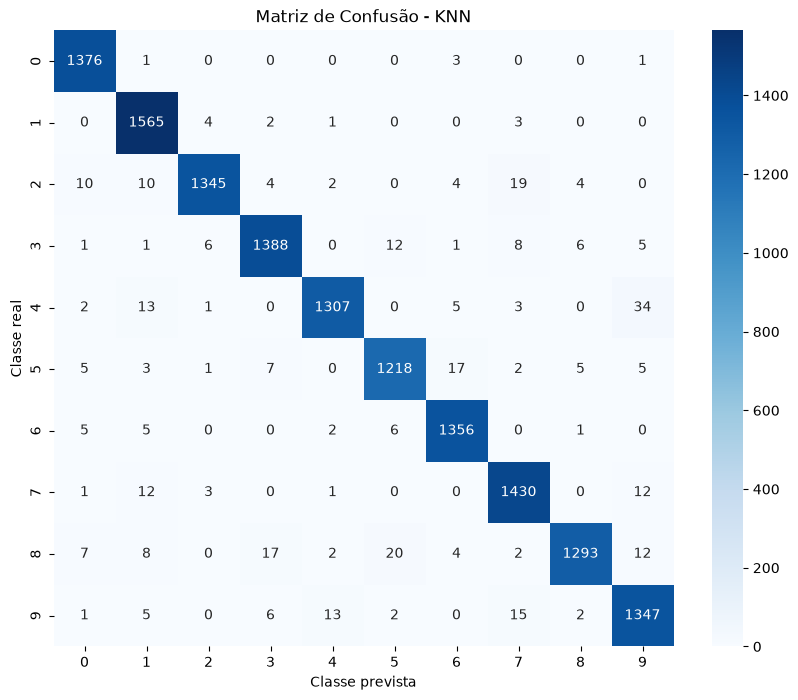

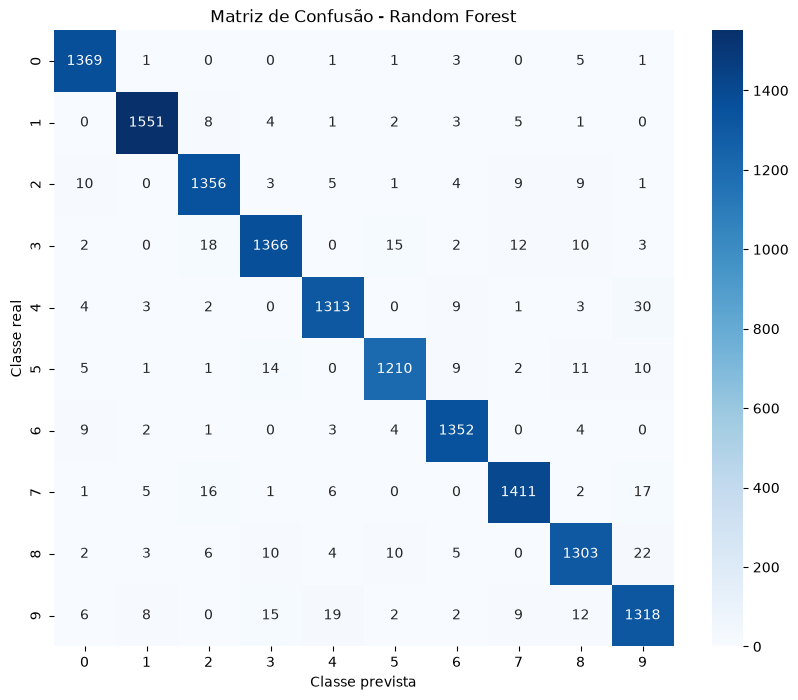

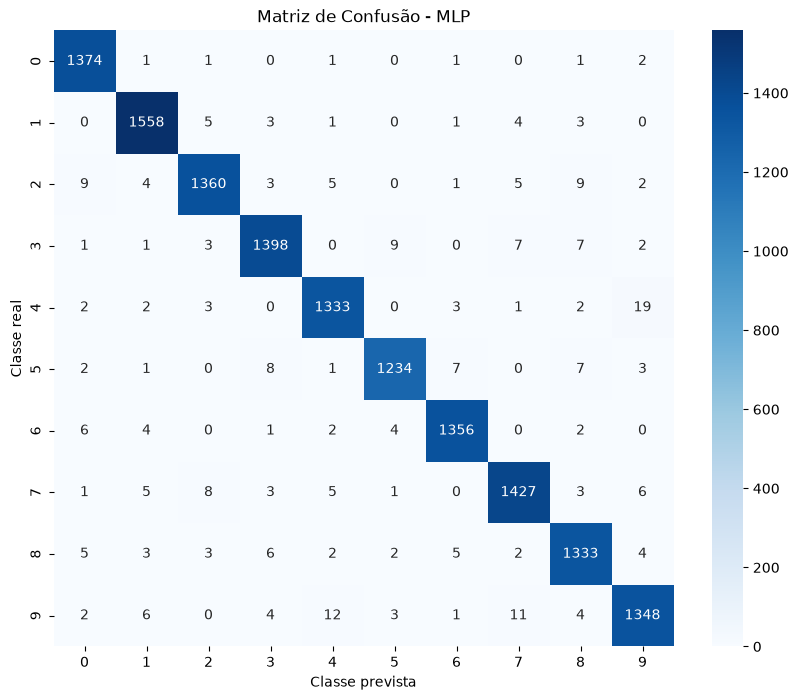

In [77]:
#Matriz de confusão para cada modelo
for nome, y_pred in predicoes.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=range(10)
    )

    plt.figure(
        figsize=(10, 8)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(10),
        yticklabels=range(10)
    )

    plt.xlabel(
        "Classe prevista"
    )

    plt.ylabel(
        "Classe real"
    )

    plt.title(
        f"Matriz de Confusão - {nome}"
    )

    plt.show()

### 4.2 Classification report

In [90]:
for nome, y_pred in predicoes.items():

    print(
        "\n",
        nome
    )

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4
        )
    )


 KNN
              precision    recall  f1-score   support

           0     0.9773    0.9964    0.9867      1381
           1     0.9643    0.9937    0.9787      1575
           2     0.9890    0.9621    0.9753      1398
           3     0.9747    0.9720    0.9734      1428
           4     0.9842    0.9575    0.9707      1365
           5     0.9682    0.9644    0.9663      1263
           6     0.9755    0.9862    0.9808      1375
           7     0.9649    0.9801    0.9725      1459
           8     0.9863    0.9473    0.9664      1365
           9     0.9513    0.9684    0.9597      1391

    accuracy                         0.9732     14000
   macro avg     0.9736    0.9728    0.9731     14000
weighted avg     0.9734    0.9732    0.9732     14000


 Random Forest
              precision    recall  f1-score   support

           0     0.9723    0.9913    0.9817      1381
           1     0.9854    0.9848    0.9851      1575
           2     0.9631    0.9700    0.9665      1398
  

### Fase 4.3 — Escolher o melhor modelo

In [92]:
melhor_nome = (
    df_resultados
    .iloc[0]["Modelo"]
)

melhor_modelo = modelos[
    melhor_nome
]

print(
    "Melhor modelo:",
    melhor_nome
)

Melhor modelo: MLP


In [78]:
from sklearn.metrics import confusion_matrix
import numpy as np

modelos_finais = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}

for nome, modelo in modelos_finais.items():

    # Predições
    y_pred = modelo.predict(X_test)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    # Total de erros por dígito
    erros_por_digito = cm.sum(axis=1) - np.diag(cm)

    # Dígito com maior número de erros
    digito_mais_confundido = np.argmax(erros_por_digito)

    print(f"\n{nome}")
    print(f"Dígito mais confundido: {digito_mais_confundido}")
    print(f"Total de erros: {erros_por_digito[digito_mais_confundido]}")


KNN
Dígito mais confundido: 8
Total de erros: 72

Random Forest
Dígito mais confundido: 9
Total de erros: 73

MLP
Dígito mais confundido: 9
Total de erros: 43


In [79]:
from sklearn.metrics import confusion_matrix
import numpy as np

modelos_finais = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}

for nome, modelo in modelos_finais.items():

    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Total de erros de cada dígito
    erros_por_digito = cm.sum(axis=1) - np.diag(cm)

    # Dígito com maior número total de erros
    digito = np.argmax(erros_por_digito)

    # Copiar a linha desse dígito
    confusoes = cm[digito].copy()

    # Retirar os acertos
    confusoes[digito] = 0

    # Classe incorreta mais frequente
    confundido_com = np.argmax(confusoes)

    print(f"\n{nome}")
    print(f"Dígito mais confundido: {digito}")
    print(f"Total de erros: {erros_por_digito[digito]}")
    print(
        f"Mais frequentemente confundido com: "
        f"{confundido_com} ({confusoes[confundido_com]} vezes)"
    )


KNN
Dígito mais confundido: 8
Total de erros: 72
Mais frequentemente confundido com: 5 (20 vezes)

Random Forest
Dígito mais confundido: 9
Total de erros: 73
Mais frequentemente confundido com: 4 (19 vezes)

MLP
Dígito mais confundido: 9
Total de erros: 43
Mais frequentemente confundido com: 4 (12 vezes)


## Análise dos dígitos mais confundidos

A partir das matrizes de confusão, foi identificado o dígito que
apresentou o maior número total de classificações incorretas em cada
modelo.

Os resultados foram:

| Modelo | Dígito mais confundido | Total de erros | Principal confusão |
|---|---:|---:|---|
| **KNN** | **8** | 72 | 8 → 5 (20 vezes) |
| **Random Forest** | **9** | 73 | 9 → 4 (19 vezes) |
| **MLP** | **9** | **43** | 9 → 4 (12 vezes) |

### KNN

No KNN, o dígito **8** apresentou o maior número total de erros,
com **72 classificações incorretas**.

Dentro desses erros, a confusão mais frequente ocorreu entre os
dígitos **8 e 5**, com o número 8 sendo classificado como 5 em
**20 casos**.

### Random Forest

No Random Forest, o dígito **9** foi o mais difícil de classificar,
apresentando **73 erros**.

A principal confusão ocorreu entre **9 e 4**, sendo o dígito 9
classificado como 4 em **19 casos**.

### MLP

Na MLP, o dígito que apresentou maior número de erros também foi
o **9**, porém com apenas **43 classificações incorretas**.

A principal confusão ocorreu novamente com o dígito **4**, sendo
observados **12 casos de 9 classificado como 4**.

### Comparação

Os resultados mostram que os modelos apresentam dificuldades
diferentes na classificação de determinados padrões manuscritos.

O KNN apresentou maior dificuldade com o dígito **8**, principalmente
em sua diferenciação do número 5.

Já o Random Forest e a MLP apresentaram maior dificuldade com o
dígito **9**, principalmente em sua diferenciação do número 4.

Entretanto, mesmo considerando sua classe com maior número de erros,
a **MLP apresentou somente 43 erros**, valor consideravelmente menor
que os 72 erros do KNN e os 73 erros do Random Forest.

Essa análise das matrizes de confusão reforça os resultados das
métricas globais e contribui para a escolha da **MLP como o modelo
de melhor desempenho geral**.

### Salvando as imagens das matrizes de confusão:

Pasta das figuras:
E:\SENAI\Miniprojeto MNIST\SENAI-Miniprojeto-MNIST\reports\figures


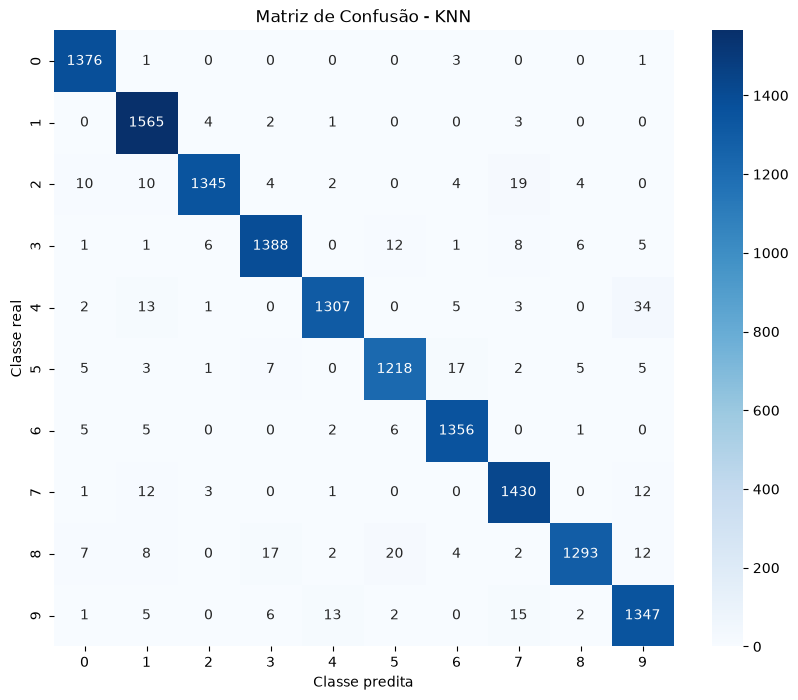

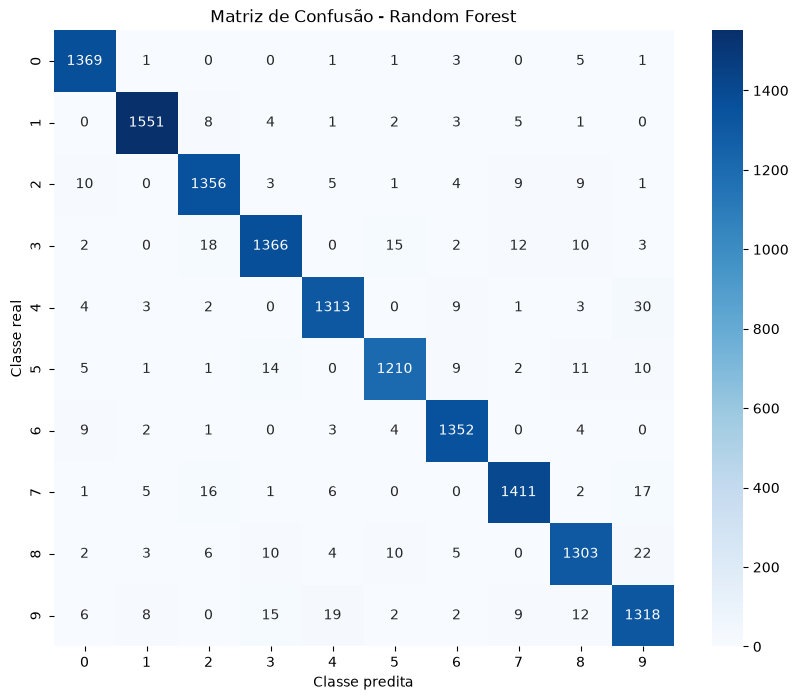

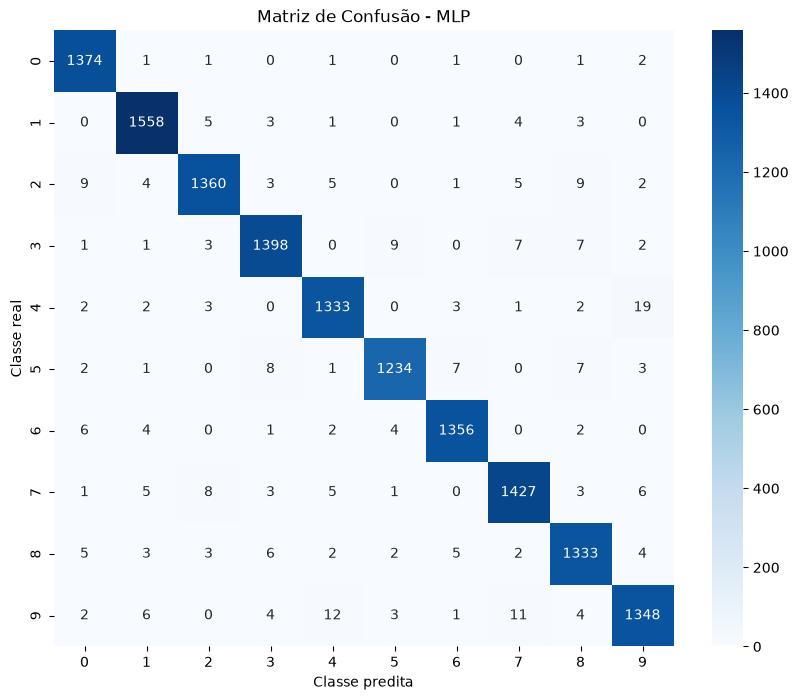

In [85]:

#Salvando as matrizes de confusão como imagens
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


from pathlib import Path

# Pasta onde as figuras serão armazenadas
PASTA_FIGURAS = Path("../reports/figures")

# Cria a pasta caso ela ainda não exista
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Pasta das figuras:")
print(PASTA_FIGURAS.resolve())

modelos = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}

nomes_arquivos = {
    "KNN": "matriz_confusao_knn.png",
    "Random Forest": "matriz_confusao_random_forest.png",
    "MLP": "matriz_confusao_mlp.png"
}

for nome, modelo in modelos.items():

    # Realiza as predições
    y_pred = modelo.predict(X_test)

    # Calcula a matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    # Cria o gráfico
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Classe predita")
    plt.ylabel("Classe real")

    # Salva a figura
    plt.savefig(
        PASTA_FIGURAS / nomes_arquivos[nome],
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

### Salvando as imagens das métricas e tempo de treinamento:

In [86]:
import pandas as pd

resultados_finais = pd.DataFrame({
    "Modelo": ["MLP", "KNN", "Random Forest"],
    "Accuracy": [0.980071, 0.973214, 0.967786],
    "Precision": [0.980077, 0.973408, 0.967806],
    "Recall": [0.980071, 0.973214, 0.967786],
    "F1": [0.980062, 0.973185, 0.967771],
    "Tempo_treino": [64.052727, 0.180345, 31.365318],
    "Tempo_predicao": [0.126556, 25.033448, 0.708309]
})

### Comparação das métricas:

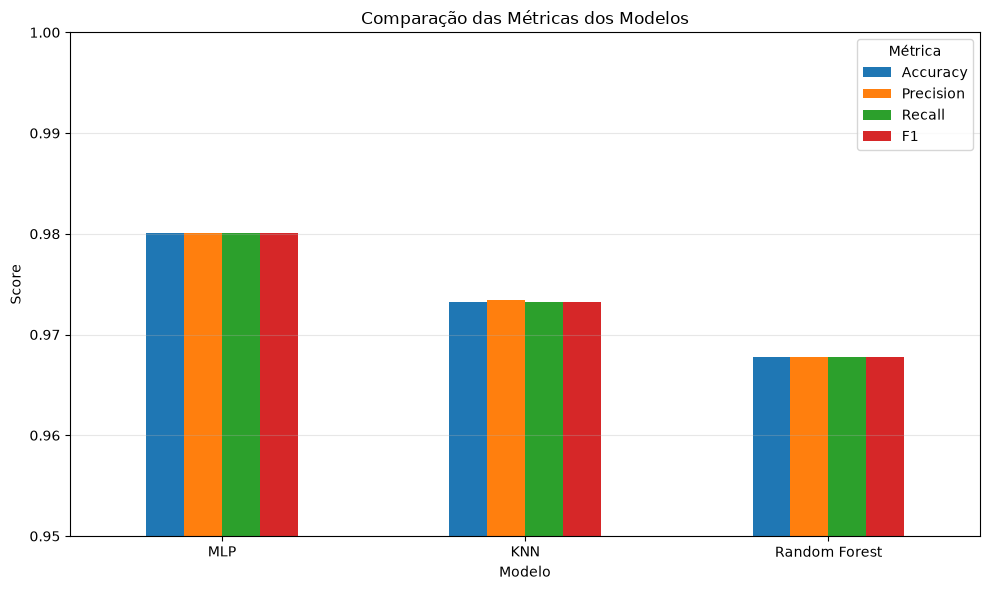

In [ ]:
#sALVANDO A FIGURA DE COMPARAÇÃO DAS MÉTRICAS
metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

ax = resultados_finais.set_index("Modelo")[metricas].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparação das Métricas dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.ylim(0.95, 1.0)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "comparacao_metricas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Comparação do tempo de treinamento

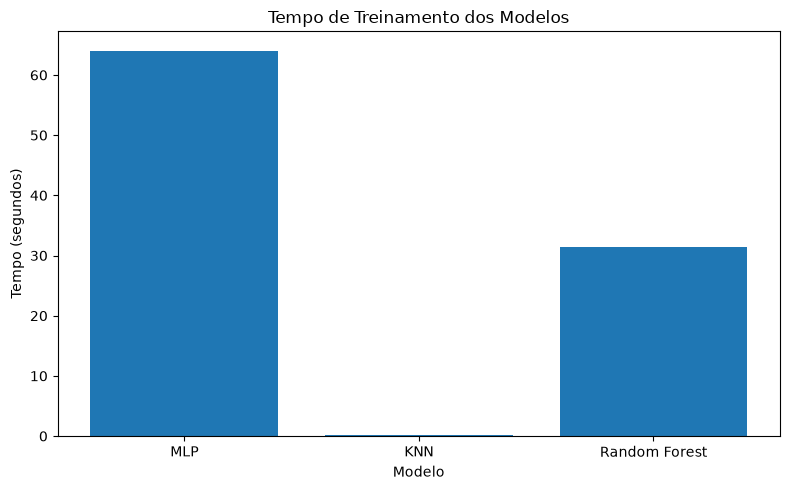

In [88]:
#sALVANDO A FIGURA DE COMPARAÇÃO DO TEMPO DE TREINAMENTO
plt.figure(figsize=(8, 5))

plt.bar(
    resultados_finais["Modelo"],
    resultados_finais["Tempo_treino"]
)

plt.title("Tempo de Treinamento dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Tempo (segundos)")

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "comparacao_tempo_treino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Comparação do tempo de predição:

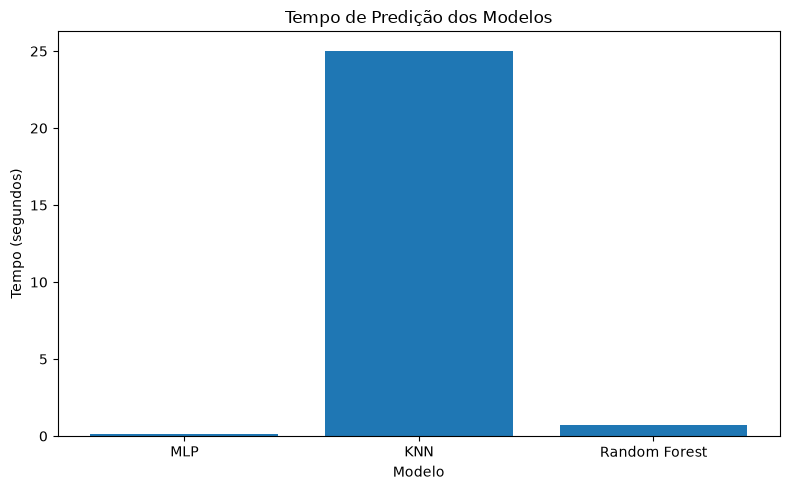

In [89]:
#Salvando a figura de comparação do tempo de predição
plt.figure(figsize=(8, 5))

plt.bar(
    resultados_finais["Modelo"],
    resultados_finais["Tempo_predicao"]
)

plt.title("Tempo de Predição dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Tempo (segundos)")

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "comparacao_tempo_predicao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Fase 5: Nos próximos sub itens da Fase 5, vocês irão testar a capacidade dos modelos de lidar com cenários fora do padrão ideal de laboratório:



### Fase 5.1 - Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

Selecione ao menos duas classes para serem totalmente removidas da base de treinamento (por exemplo: ocultar os dígitos 4 e 7).
Treine um dos seus modelos (clássico ou rede neural) sem nunca ter visto esses dois dígitos durante o ajuste dos pesos.



In [93]:
#Definindo classes ocultas

CLASSES_OCULTAS = [
    4,
    7
]

In [94]:
#Remove 4 e 7 do treinamento
mascara_treino = ~np.isin(
    y_train_final,
    CLASSES_OCULTAS
)

X_train_ood = X_train_final[
    mascara_treino
]

y_train_ood = y_train_final[
    mascara_treino
]

In [95]:
#Conferindo
print(
    np.unique(
        y_train_ood
    )
)

[0 1 2 3 5 6 8 9]


In [96]:
#Copia o melhor modelo treinado (MLP) para o conjunto de dados sem as classes ocultas
modelo_ood = clone(
    melhor_modelo
)

In [97]:
#Treinando sem 4 e 7    
modelo_ood.fit(
    X_train_ood,
    y_train_ood
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('normalizacao', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](8,)","[0,1,2,...,6,8,9]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function nor...0023694993BA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


### Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD)
Submeta o modelo treinado no Desafio A a um conjunto de teste contendo exclusivamente as classes que foram ocultadas (no exemplo: apenas imagens dos dígitos 4 e 7).
Análise e plote o comportamento do modelo:
Como o classificador reage ao ser forçado a classificar algo que nunca viu?
Quais classes conhecidas ele atribui a esses dígitos desconhecidos?


In [98]:
#Pegue somente as classes 4 e 7 do conjunto de teste
mascara_teste = np.isin(
    y_test,
    CLASSES_OCULTAS
)

X_test_ood = X_test[
    mascara_teste
]

y_test_ood = y_test[
    mascara_teste
]

In [99]:
#Faça as predições usando o modelo treinado sem 4 e 7
y_pred_ood = modelo_ood.predict(
    X_test_ood
)

In [100]:
tabela_ood = pd.crosstab(
    pd.Series(
        y_test_ood,
        name="Real"
    ),

    pd.Series(
        y_pred_ood,
        name="Previsto"
    )
)

display(
    tabela_ood
)

Previsto,0,1,2,3,5,6,8,9
Real,,,,,,,,
4,4,10,52,8,14,76,56,1145
7,15,36,265,407,14,0,32,690


## 5.2 Avaliação com classes ocultas (4 e 7)

Para avaliar o comportamento do modelo diante de classes não conhecidas
durante o treinamento, foi realizado um experimento no qual os dígitos
**4 e 7 foram removidos do conjunto de treinamento**.

Dessa forma, o modelo foi treinado utilizando somente as classes:

**0, 1, 2, 3, 5, 6, 8 e 9.**

Posteriormente, foram apresentadas ao modelo imagens pertencentes às
classes ocultas **4 e 7**. Como essas classes não faziam parte das
possibilidades aprendidas durante o treinamento, o modelo necessariamente
classificou essas imagens como uma das oito classes conhecidas.

### Resultados para o dígito 4

O dígito **4** foi predominantemente classificado como **9**, ocorrendo
essa previsão em **1.145 casos**.

Outras classificações observadas foram:

- 4 → 6: 76 casos;
- 4 → 8: 56 casos;
- 4 → 2: 52 casos;
- 4 → 5: 14 casos;
- 4 → 1: 10 casos;
- 4 → 3: 8 casos;
- 4 → 0: 4 casos.

O resultado demonstra uma forte associação do padrão visual do dígito
4 com o dígito 9 quando a classe correta não está disponível para o
classificador.

### Resultados para o dígito 7

O dígito **7** também foi classificado principalmente como **9**, com
**690 ocorrências**.

Entretanto, houve uma distribuição maior entre outras classes conhecidas,
principalmente:

- 7 → 3: 407 casos;
- 7 → 2: 265 casos;
- 7 → 1: 36 casos;
- 7 → 8: 32 casos;
- 7 → 0: 15 casos;
- 7 → 5: 14 casos;
- 7 → 6: 0 casos.

### Interpretação

O experimento evidencia uma limitação importante dos classificadores
supervisionados tradicionais: quando recebem uma amostra pertencente a
uma classe que não estava presente durante o treinamento, eles não
identificam automaticamente que se trata de uma classe desconhecida.

Em vez disso, o modelo atribui a amostra a uma das classes que aprendeu.

Neste experimento, tanto o dígito **4** quanto o dígito **7** foram
associados com maior frequência ao dígito **9**. No caso do 4, essa
associação foi particularmente forte, enquanto as imagens do dígito 7
foram distribuídas de maneira mais significativa também entre as classes
3 e 2.

Portanto, o experimento com classes ocultas demonstra a diferença entre
**classificação incorreta de uma classe conhecida** e o comportamento do
modelo diante de uma **classe ausente do treinamento**.

### Fase 5.2.1 — Overconfidence

In [102]:
#Calculando as probabilidades de cada classe para as amostras de teste com classes ocultas
probabilidades_ood = (
    modelo_ood.predict_proba(
        X_test_ood
    )
)

In [202]:
#Pega a maior probalidade de cada amostra, que representa a confiança do modelo na predição
confianca_ood = (
    probabilidades_ood
    .max(axis=1)
)

In [201]:
#Mostra a confiança média, máxima e mínima do modelo para as amostras de teste com classes ocultas
print(
    "Confiança média:",
    confianca_ood.mean()
)

print(
    "Confiança máxima:",
    confianca_ood.max()
)

print(
    "Confiança mínima:",
    confianca_ood.min()
)

Confiança média: 0.9166176
Confiança máxima: 1.0
Confiança mínima: 0.32259402


### 5.2 Avaliação com classes ocultas e análise de overconfidence

Neste experimento, os dígitos **4 e 7 foram ocultados durante o
treinamento**, de modo que o modelo foi treinado apenas com as classes
**0, 1, 2, 3, 5, 6, 8 e 9**.

Posteriormente, foram apresentadas ao modelo amostras pertencentes
exclusivamente às classes ocultas 4 e 7. Como essas classes não faziam
parte das possibilidades aprendidas pelo classificador, o modelo foi
obrigado a associar cada imagem a uma das classes conhecidas.

A matriz de confusão obtida foi:

| Classe real | 0 | 1 | 2 | 3 | 5 | 6 | 8 | 9 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| **4** | 4 | 10 | 52 | 8 | 14 | 76 | 56 | **1145** |
| **7** | 15 | 36 | 265 | 407 | 14 | 0 | 32 | **690** |

### Impressões sobre o teste

Os resultados mostram que o modelo não foi capaz de reconhecer as
amostras como pertencentes a classes desconhecidas. Em vez disso,
atribuiu todas as imagens a alguma das classes disponíveis durante o
treinamento.

Para o dígito **4**, houve uma forte concentração das previsões na
classe **9**, com **1.145 ocorrências**.

O dígito **7** também foi classificado principalmente como **9**, com
**690 ocorrências**, porém apresentou maior dispersão das previsões,
especialmente para as classes **3 (407 casos)** e **2 (265 casos)**.

Esse comportamento mostra que, diante de uma classe desconhecida, o
classificador procura o padrão conhecido que considera mais semelhante,
em vez de indicar que não reconhece a entrada.

### Confiança das previsões

A análise das probabilidades produzidas pelo modelo apresentou:

- **Confiança média:** 91,66%
- **Confiança máxima:** 100,00%
- **Confiança mínima:** 32,26%

O valor mais relevante é a confiança média de **91,66%**. Mesmo diante
de imagens pertencentes a classes que nunca foram apresentadas durante
o treinamento, o modelo demonstrou, em média, elevada confiança nas
classes incorretamente atribuídas.

### Falsa certeza (overconfidence)

Esse comportamento exemplifica o fenômeno conhecido como
**overconfidence**, ou falsa certeza.

Um modelo apresenta overconfidence quando atribui uma probabilidade
muito elevada a determinada previsão mesmo quando essa previsão não é
confiável ou quando a entrada está fora das condições para as quais o
modelo foi treinado.

Neste experimento, os dígitos 4 e 7 constituem exemplos de dados
**fora da distribuição conhecida pelo modelo (Out-of-Distribution - OOD)**,
pois essas classes foram deliberadamente excluídas do treinamento.

Apesar disso, o modelo não possui, por padrão, uma opção equivalente a
"classe desconhecida". Ele continua produzindo probabilidades para as
classes disponíveis e seleciona aquela com maior valor.

Assim, uma previsão com alta probabilidade não deve ser interpretada
automaticamente como garantia de que a classificação está correta.

O experimento demonstra uma questão importante para aplicações reais de
Inteligência Artificial: além da acurácia em dados conhecidos, é
necessário considerar como o sistema se comporta diante de situações
diferentes daquelas observadas durante o treinamento. Um modelo pode
estar errado e, ao mesmo tempo, apresentar elevada confiança em sua
decisão.

### Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias
Deve-se escrever manualmente um dígito em folha de papel branco com caneta escura (ou desenhar no Paint/GIMP com fundo preto e traço branco). 
Note que dependendo de sua escolha o pipeline de pré-processamento vai ser diferente.
Digitalize / fotografe as imagens e construa um pipeline de pré-processamento em Python (usando por exemplo PIL/OpenCV) contendo:
Conversão para escala de cinza;
Inversão de cores (caso o papel seja branco com traço preto);
Redimensionamento para 28 x 28 pixels com centralização de massa/bounding box;
Normalização para o intervalo [0.0, 1.0].
Realize a predição das suas imagens próprias utilizando o melhor modelo desenvolvido e plote a imagem processada ao lado do gráfico de probabilidades de saída.


In [203]:
#Preparar imagem para predição
def preparar_imagem(
    caminho
):

    imagem = Image.open(
        caminho
    ).convert("L")

    array = np.array(
        imagem
    )

    # Inverte:
    # fundo branco → preto
    # tinta preta → branco
    array = (
        255 - array
    )

    array[
        array < 30
    ] = 0

    coords = np.argwhere(
        array > 0
    )

    if len(coords) == 0:

        raise ValueError(
            "Nenhum dígito detectado."
        )

    y_min, x_min = (
        coords.min(axis=0)
    )

    y_max, x_max = (
        coords.max(axis=0)
        + 1
    )

    recorte = array[
        y_min:y_max,
        x_min:x_max
    ]

    imagem_recorte = (
        Image.fromarray(
            recorte.astype(
                np.uint8
            )
        )
    )

    largura, altura = (
        imagem_recorte.size
    )

    if largura > altura:

        nova_largura = 20

        nova_altura = max(
            1,
            round(
                altura
                * 20
                / largura
            )
        )

    else:

        nova_altura = 20

        nova_largura = max(
            1,
            round(
                largura
                * 20
                / altura
            )
        )

    imagem_recorte = (
        imagem_recorte.resize(
            (
                nova_largura,
                nova_altura
            ),
            Image.Resampling.LANCZOS
        )
    )

    canvas = np.zeros(
        (28, 28),
        dtype=np.uint8
    )

    y_inicio = (
        28 - nova_altura
    ) // 2

    x_inicio = (
        28 - nova_largura
    ) // 2

    canvas[
        y_inicio:
        y_inicio + nova_altura,

        x_inicio:
        x_inicio + nova_largura
    ] = np.array(
        imagem_recorte
    )

    return canvas

In [204]:
caminho = Path(
    "../images/raw/digito_5P.jpg"
)

imagem_processada = preparar_imagem(
    caminho
)

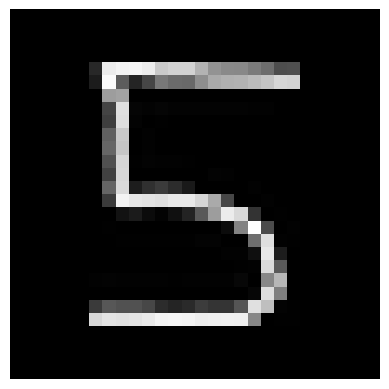

In [205]:
#Verificando a imagem processada
plt.imshow(
    imagem_processada,
    cmap="gray"
)

plt.axis(
    "off"
)

plt.show()

In [194]:
X_novo = (
    imagem_processada
    .reshape(
        1,
        784
    )
)

In [195]:
#Faca a predição usando o melhor modelo treinado
predicao = (
    melhor_modelo
    .predict(
        X_novo
    )[0]
)

print(
    "Dígito previsto:",
    predicao
)

Dígito previsto: 5


In [206]:
#Calculando as probabilidades de cada classe para a nova amostra
probabilidades = (
    melhor_modelo
    .predict_proba(
        X_novo
    )[0]
)

In [207]:
#Classes do melhor modelo treinado
classes = (
    melhor_modelo
    .named_steps["modelo"]
    .classes_
)

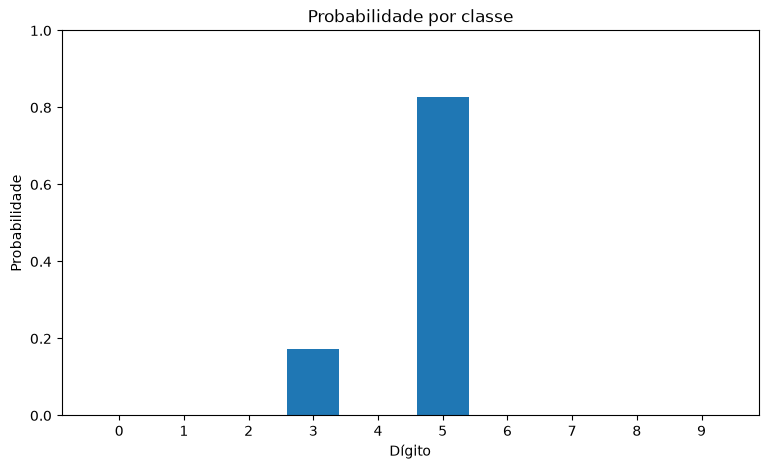

In [208]:
#Gráfico de barras das probabilidades por classe
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    classes.astype(str),
    probabilidades
)

plt.xlabel(
    "Dígito"
)

plt.ylabel(
    "Probabilidade"
)

plt.title(
    "Probabilidade por classe"
)

plt.ylim(
    0,
    1
)

plt.show()

#################################################################

## 5.3 Desafio (C) — Inferência com Imagens Manuscritas Próprias

Nesta etapa, o objetivo é avaliar a capacidade de generalização do melhor
modelo desenvolvido utilizando imagens externas ao conjunto MNIST.

Foram utilizadas três imagens próprias representando o dígito **5**.
As imagens foram produzidas em condições diferentes, incluindo escrita
manual em papel e desenho digital.

Como essas imagens não possuem necessariamente o mesmo padrão visual das
imagens do MNIST, foi necessário aplicar um pipeline de pré-processamento
para aproximá-las do formato utilizado durante o treinamento.

O pré-processamento inclui:

- conversão para escala de cinza;
- inversão de cores quando necessário;
- identificação da região contendo o dígito;
- redimensionamento e centralização;
- ajuste para 28 × 28 pixels;
- normalização dos pixels para o intervalo [0.0, 1.0].

Após o pré-processamento, cada imagem será submetida ao modelo MLP final
e serão analisadas as probabilidades atribuídas às dez classes.

In [209]:
#Importando bibliotecas necessárias
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

In [211]:
PASTA_IMAGENS = Path("../images/raw")
PASTA_FIGURAS = Path("../images/processed")

PASTA_FIGURAS.mkdir(
    parents=True,
    exist_ok=True
)

In [221]:
#Processa a imagem e salva o resultado
def preprocessar_imagem(caminho):
    
    # 1. Carrega a imagem
    imagem = Image.open(caminho)

    # 2. Converte para escala de cinza
    imagem = imagem.convert("L")

    # 3. Inverte as cores
    # MNIST: fundo preto e dígito claro
    imagem = ImageOps.invert(imagem)

    # Converte temporariamente para array
    img_array = np.array(imagem)

    # 4. Localiza pixels relevantes do dígito
    mascara = img_array > 30

    coordenadas = np.argwhere(mascara)

    if coordenadas.size == 0:
        raise ValueError(
            f"Nenhum dígito foi detectado na imagem: {caminho}"
        )

    y_min, x_min = coordenadas.min(axis=0)
    y_max, x_max = coordenadas.max(axis=0)

    # Recorta somente a região do dígito
    imagem = imagem.crop(
        (x_min, y_min, x_max + 1, y_max + 1)
    )

    # 5. Redimensiona mantendo proporção
    imagem.thumbnail(
        (20, 20),
        Image.Resampling.LANCZOS
    )

    # 6. Cria fundo preto 28x28
    canvas = Image.new(
        "L",
        (28, 28),
        0
    )

    # Centraliza a imagem
    x = (28 - imagem.width) // 2
    y = (28 - imagem.height) // 2

    canvas.paste(
        imagem,
        (x, y)
    )

    # 7. Converte para array
    img_array = np.array(
        canvas,
        dtype=np.float32
    )

    # 8. Normaliza para [0, 1]
    #img_array /= 255.0

    return img_array

In [222]:
imagens_teste = {
    "Manuscrito 1": PASTA_IMAGENS / "digito_5PaintF.jpg",
    "Manuscrito 2": PASTA_IMAGENS / "digito_5PaintM.jpg",
    "Manuscrito 3": PASTA_IMAGENS / "digito_5PaintG.jpg"
}

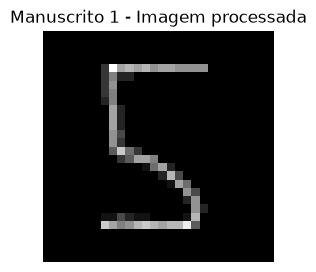

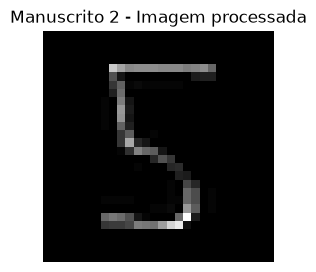

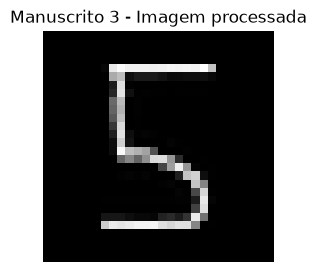

In [223]:
for nome, caminho in imagens_teste.items():

    imagem_processada = preprocessar_imagem(
        caminho
    )

    plt.figure(figsize=(3, 3))

    plt.imshow(
        imagem_processada,
        cmap="gray"
    )

    plt.title(
        f"{nome} - Imagem processada"
    )

    plt.axis("off")
    plt.show()

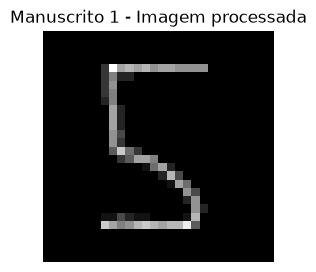

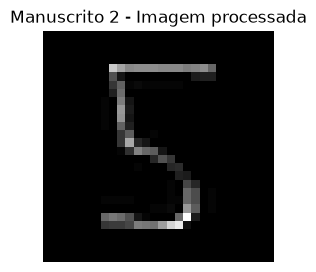

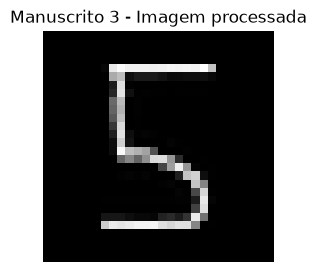

In [187]:
#Visualizar as imagens processadas
for nome, caminho in imagens_teste.items():

    imagem_processada = preprocessar_imagem(
        caminho
    )

    plt.figure(figsize=(3, 3))

    plt.imshow(
        imagem_processada,
        cmap="gray"
    )

    plt.title(
        f"{nome} - Imagem processada"
    )

    plt.axis("off")
    plt.show()

In [224]:
#Fazer predição para cada imagem de teste
resultados_imagens = []

for nome, caminho in imagens_teste.items():

    imagem_processada = preprocessar_imagem(
        caminho
    )

    # Transforma 28x28 em 784 atributos
    entrada = imagem_processada.reshape(
        1,
        -1
    )

    # Predição
    predicao = mlp_final.predict(
        entrada
    )[0]

    # Probabilidades
    probabilidades = mlp_final.predict_proba(
        entrada
    )[0]

    # Confiança máxima
    confianca = probabilidades.max()

    resultados_imagens.append({
        "Imagem": nome,
        "Real": 5,
        "Previsto": predicao,
        "Confiança": confianca
    })

    print(
        f"{nome}: "
        f"real = 5 | "
        f"previsto = {predicao} | "
        f"confiança = {confianca:.2%}"
    )


Manuscrito 1: real = 5 | previsto = 5 | confiança = 32.63%
Manuscrito 2: real = 5 | previsto = 5 | confiança = 60.26%
Manuscrito 3: real = 5 | previsto = 5 | confiança = 99.69%


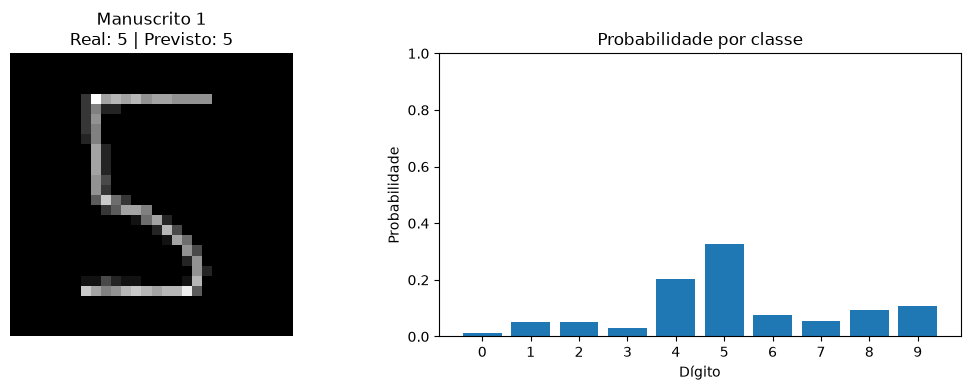

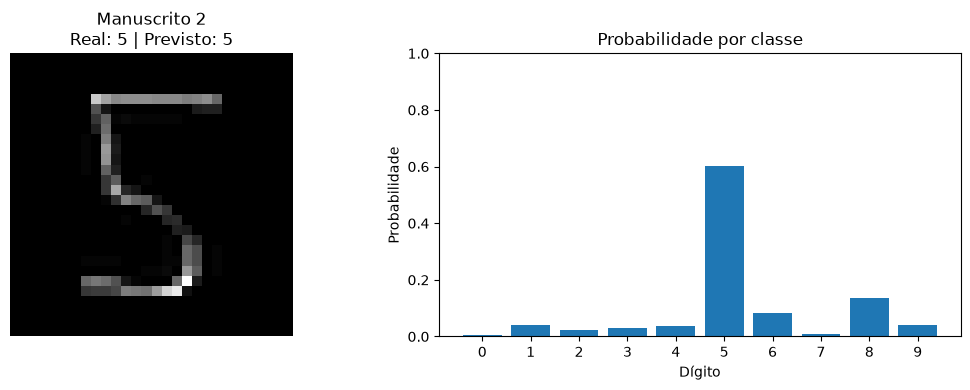

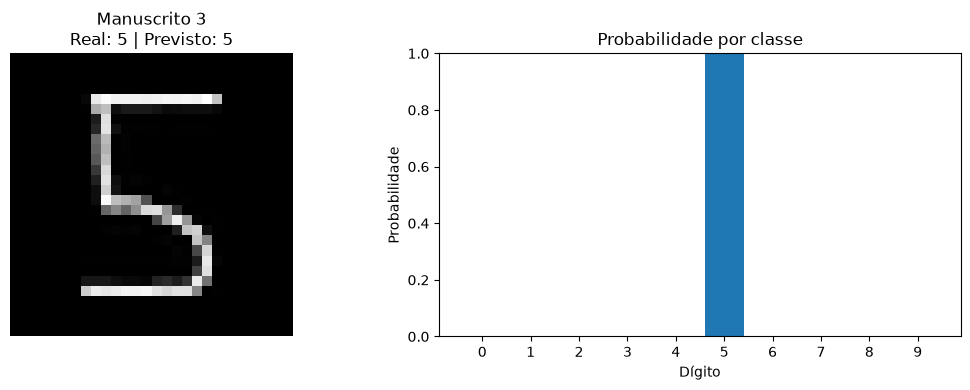

In [225]:
#Imagem processada ao lado das probabilidades por classe
for nome, caminho in imagens_teste.items():

    imagem_processada = preprocessar_imagem(
        caminho
    )

    entrada = imagem_processada.reshape(
        1,
        -1
    )

    predicao = mlp_final.predict(
        entrada
    )[0]

    probabilidades = mlp_final.predict_proba(
        entrada
    )[0]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4)
    )

    # Imagem processada
    axes[0].imshow(
        imagem_processada,
        cmap="gray"
    )

    axes[0].set_title(
        f"{nome}\nReal: 5 | Previsto: {predicao}"
    )

    axes[0].axis("off")

    # Probabilidades
    axes[1].bar(
        range(10),
        probabilidades
    )

    axes[1].set_title(
        "Probabilidade por classe"
    )

    axes[1].set_xlabel(
        "Dígito"
    )

    axes[1].set_ylabel(
        "Probabilidade"
    )

    axes[1].set_xticks(
        range(10)
    )

    axes[1].set_ylim(
        0,
        1
    )

    plt.tight_layout()

    nome_arquivo = (
        nome.lower()
        .replace(" ", "_")
    )

    plt.savefig(
        PASTA_FIGURAS /
        f"predicao_{nome_arquivo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [226]:
#Tabela comparativa dos resultados das imagens de teste
import pandas as pd

df_imagens = pd.DataFrame(
    resultados_imagens
)

df_imagens

,Imagem,Real,Previsto,Confiança
0,Manuscrito 1,5,5,0.326260
1,Manuscrito 2,5,5,0.602646
2,Manuscrito 3,5,5,0.996860


In [227]:
#Confiança média das predições para as imagens de teste
df_imagens["Confiança (%)"] = (
    df_imagens["Confiança"] * 100
).round(2)

df_imagens[
    [
        "Imagem",
        "Real",
        "Previsto",
        "Confiança (%)"
    ]
]

,Imagem,Real,Previsto,Confiança (%)
0,Manuscrito 1,5,5,32.630001
1,Manuscrito 2,5,5,60.259998
2,Manuscrito 3,5,5,99.690002


In [228]:
df_imagens["Resultado"] = np.where(
    df_imagens["Real"] ==
    df_imagens["Previsto"],
    "Correto",
    "Incorreto"
)

df_imagens[
    [
        "Imagem",
        "Real",
        "Previsto",
        "Confiança (%)",
        "Resultado"
    ]
]

,Imagem,Real,Previsto,Confiança (%),Resultado
0,Manuscrito 1,5,5,32.630001,Correto
1,Manuscrito 2,5,5,60.259998,Correto
2,Manuscrito 3,5,5,99.690002,Correto


#########################################################

In [229]:
for nome, caminho in imagens_teste.items():

    imagem_processada = preprocessar_imagem(caminho)
    entrada = imagem_processada.reshape(1, -1)

    probabilidades = mlp_final.predict_proba(entrada)[0]

    print(f"\n{nome}")
    print("Mínimo:", imagem_processada.min())
    print("Máximo:", imagem_processada.max())
    print("Média dos pixels:", imagem_processada.mean())
    print("Soma dos pixels:", imagem_processada.sum())

    print("\nProbabilidades:")

    for classe, prob in enumerate(probabilidades):
        print(f"{classe}: {prob:.4%}")


Manuscrito 1
Mínimo: 0.0
Máximo: 14.0
Média dos pixels: 0.62117344
Soma dos pixels: 487.0

Probabilidades:
0: 1.0733%
1: 5.1030%
2: 5.0000%
3: 3.0061%
4: 20.2700%
5: 32.6260%
6: 7.5414%
7: 5.4247%
8: 9.1910%
9: 10.7645%

Manuscrito 2
Mínimo: 0.0
Máximo: 47.0
Média dos pixels: 1.6454082
Soma dos pixels: 1290.0

Probabilidades:
0: 0.5727%
1: 3.9110%
2: 2.1772%
3: 2.8332%
4: 3.5520%
5: 60.2646%
6: 8.1394%
7: 0.9006%
8: 13.5453%
9: 4.1039%

Manuscrito 3
Mínimo: 0.0
Máximo: 173.0
Média dos pixels: 11.589286
Soma dos pixels: 9086.0

Probabilidades:
0: 0.0000%
1: 0.0035%
2: 0.0004%
3: 0.0160%
4: 0.0000%
5: 99.6860%
6: 0.0052%
7: 0.0000%
8: 0.2889%
9: 0.0000%


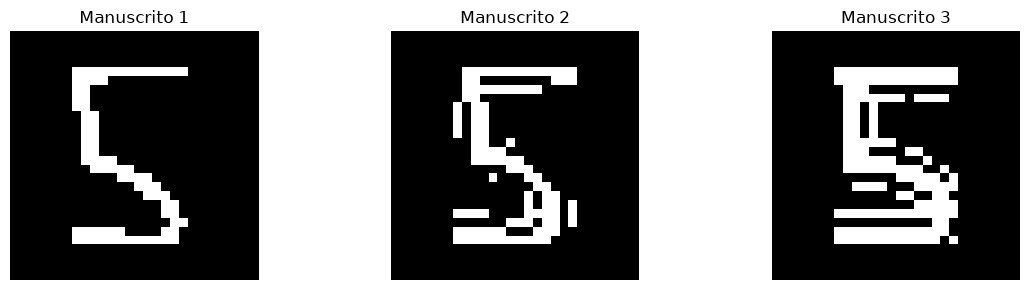

In [230]:
fig, axes = plt.subplots(
    1,
    len(imagens_teste),
    figsize=(12, 3)
)

for ax, (nome, caminho) in zip(
    axes,
    imagens_teste.items()
):

    imagem_processada = preprocessar_imagem(caminho)

    ax.imshow(
        imagem_processada,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(nome)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [231]:
print(mlp_final)

Pipeline(steps=[('normalizacao',
                 FunctionTransformer(func=<function normalizar_pixels at 0x0000023694993BA0>)),
                ('modelo',
                 MLPClassifier(alpha=0.001, early_stopping=True,
                               hidden_layer_sizes=(128, 64), max_iter=100,
                               random_state=42))])


In [218]:
print(mlp_final.named_steps)

{'normalizacao': FunctionTransformer(func=<function normalizar_pixels at 0x0000023694993BA0>), 'modelo': MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(128, 64),
              max_iter=100, random_state=42)}


In [232]:
imagem_processada = preprocessar_imagem(
    imagens_teste["Manuscrito 3"]
)

print("Mínimo:", imagem_processada.min())
print("Máximo:", imagem_processada.max())
print("Média:", imagem_processada.mean())

Mínimo: 0.0
Máximo: 173.0
Média: 11.589286


In [233]:
import inspect

print(inspect.getsource(normalizar_pixels))

def normalizar_pixels(X):

    return (
        X.astype(np.float32)
        / 255.0
    )



In [234]:
imagem_processada = preprocessar_imagem(
    imagens_teste["Manuscrito 3"]
)

print("Mínimo:", imagem_processada.min())
print("Máximo:", imagem_processada.max())
print("Média:", imagem_processada.mean())

Mínimo: 0.0
Máximo: 173.0
Média: 11.589286


In [235]:
for nome, caminho in imagens_teste.items():

    imagem_processada = preprocessar_imagem(caminho)

    entrada = imagem_processada.reshape(1, -1)

    predicao = mlp_final.predict(entrada)[0]

    probabilidades = mlp_final.predict_proba(entrada)[0]

    confianca = probabilidades.max()

    print(
        f"{nome}: "
        f"real = 5 | "
        f"previsto = {predicao} | "
        f"confiança = {confianca:.2%}"
    )
    

Manuscrito 1: real = 5 | previsto = 5 | confiança = 32.63%
Manuscrito 2: real = 5 | previsto = 5 | confiança = 60.26%
Manuscrito 3: real = 5 | previsto = 5 | confiança = 99.69%


#############################################################################

In [244]:
#Importando bibliotecas 
PASTA_IMAGENS = Path("../images/raw")
PASTA_FIGURAS = Path("../images/processed/")

PASTA_FIGURAS.mkdir(
    parents=True,
    exist_ok=True
)

In [251]:
imagens_teste = {
    "Celular - Fino": PASTA_IMAGENS / "digito_5camf.jpg",
    "Celular - Médio": PASTA_IMAGENS / "digito_5camm.jpg",
    "Celular - Grosso": PASTA_IMAGENS / "digito_5camg.jpg",

    "Scanner - Fino": PASTA_IMAGENS / "digito_5fc.jpg",
    "Scanner - Médio": PASTA_IMAGENS / "digito_5mc.jpg",
    "Scanner - Grosso": PASTA_IMAGENS / "digito_5gc.jpg",

    "Paint - Fino": PASTA_IMAGENS / "digito_5PaintF.jpg",
    "Paint - Médio": PASTA_IMAGENS / "digito_5PaintM.jpg",
    "Paint - Grosso": PASTA_IMAGENS / "digito_5PaintG.jpg"
}

In [252]:
#Processar as imagens de teste 
def preprocessar_imagem(caminho):

    imagem = Image.open(caminho)

    # Escala de cinza
    imagem = imagem.convert("L")

    # Inverte: fundo branco -> preto
    imagem = ImageOps.invert(imagem)

    img_array = np.array(imagem)

    # Detecta região do dígito
    mascara = img_array > 30
    coordenadas = np.argwhere(mascara)

    if coordenadas.size == 0:
        raise ValueError(
            f"Nenhum dígito detectado em {caminho}"
        )

    y_min, x_min = coordenadas.min(axis=0)
    y_max, x_max = coordenadas.max(axis=0)

    # Bounding box
    imagem = imagem.crop(
        (
            x_min,
            y_min,
            x_max + 1,
            y_max + 1
        )
    )

    # Redimensiona mantendo proporção
    imagem.thumbnail(
        (20, 20),
        Image.Resampling.LANCZOS
    )

    # Canvas MNIST 28x28
    canvas = Image.new(
        "L",
        (28, 28),
        0
    )

    x = (28 - imagem.width) // 2
    y = (28 - imagem.height) // 2

    canvas.paste(
        imagem,
        (x, y)
    )

    # IMPORTANTE:
    # mantém escala 0-255 porque mlp_final já normaliza
    img_array = np.array(
        canvas,
        dtype=np.float32
    )

    return img_array

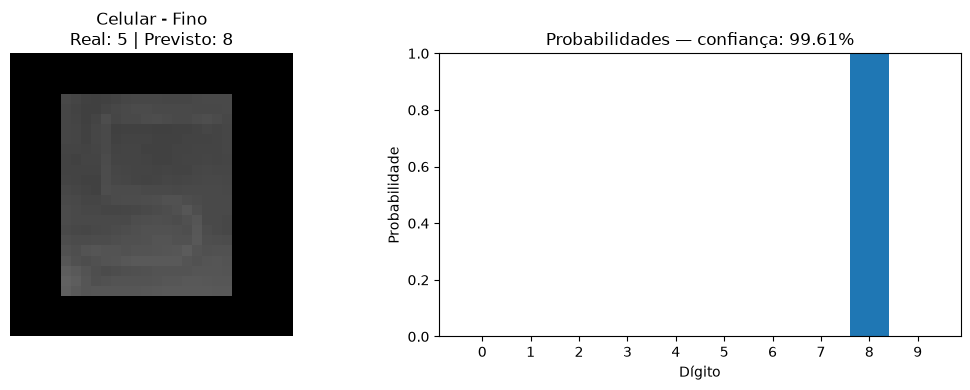

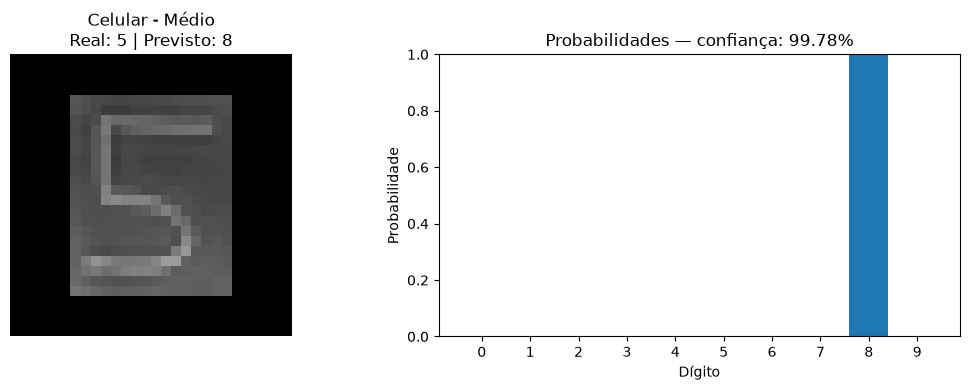

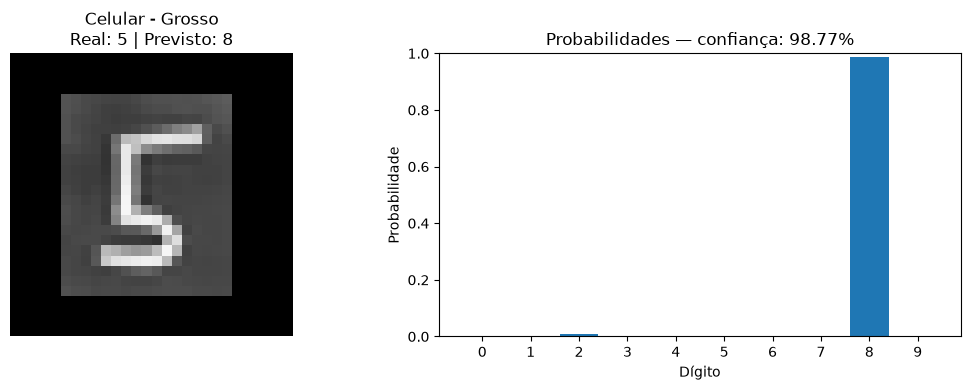

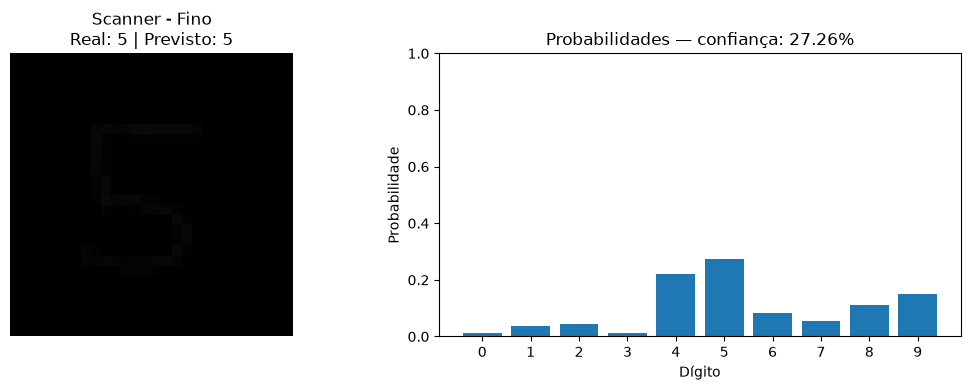

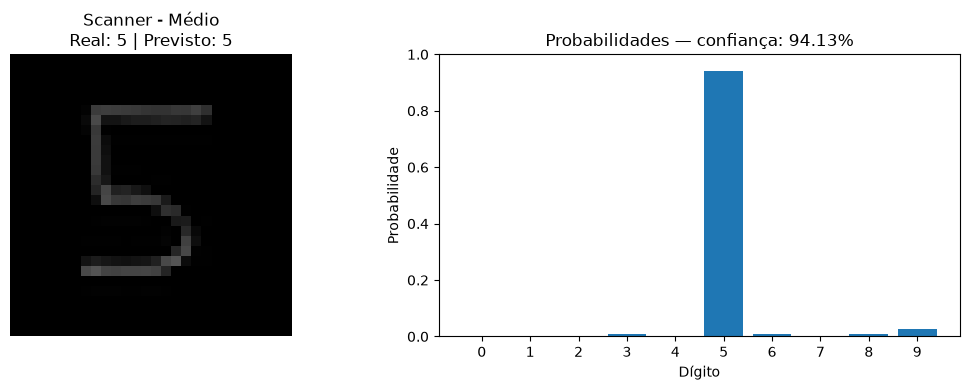

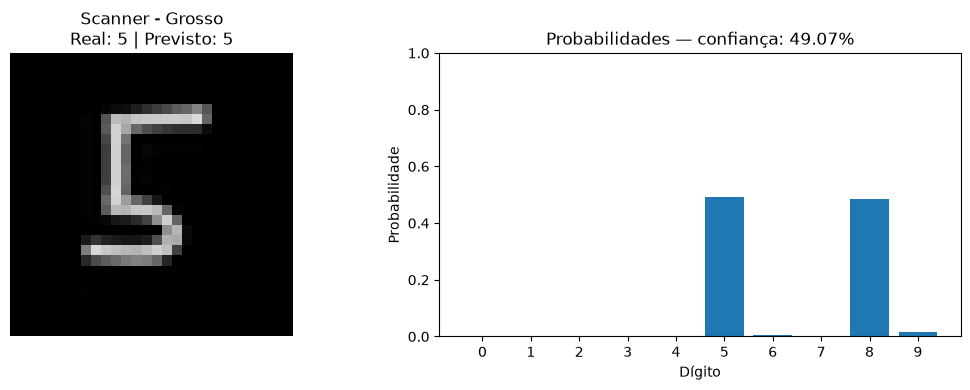

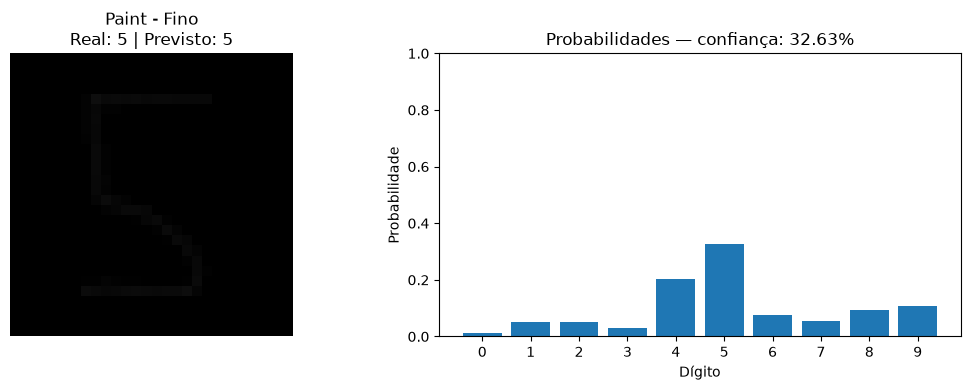

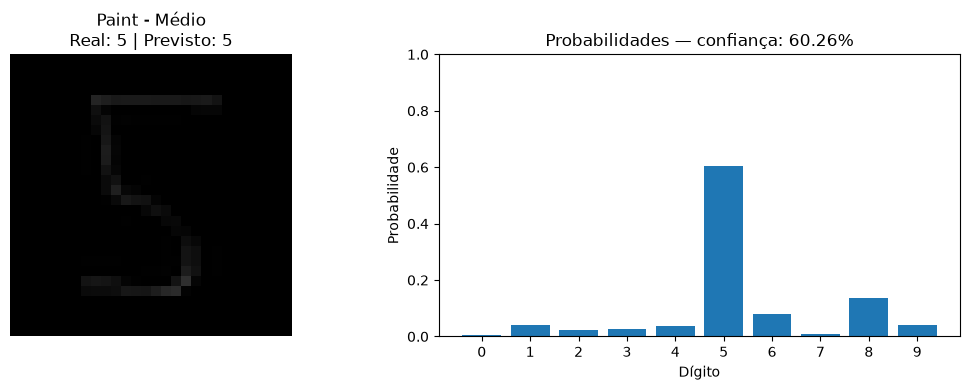

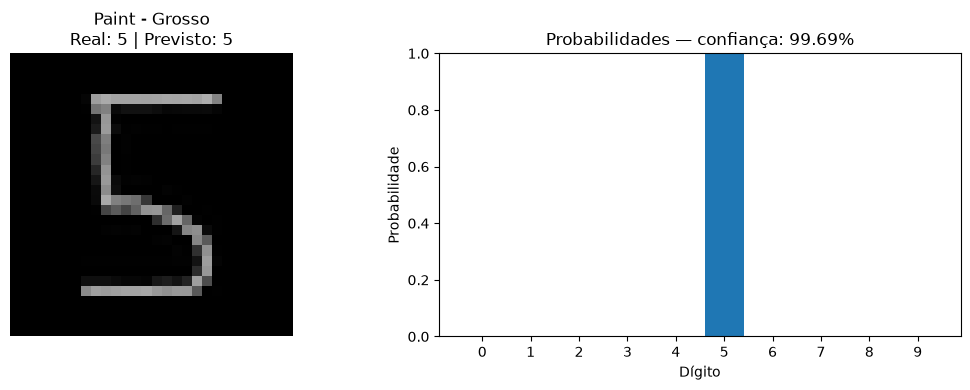

In [253]:
resultados_5_3 = []

for nome, caminho in imagens_teste.items():

    # Pré-processamento
    imagem_processada = preprocessar_imagem(
        caminho
    )

    entrada = imagem_processada.reshape(
        1,
        -1
    )

    # Predição
    predicao = int(
        mlp_final.predict(entrada)[0]
    )

    # Probabilidades
    probabilidades = mlp_final.predict_proba(
        entrada
    )[0]

    confianca = float(
        probabilidades.max()
    )

    resultado = (
        "Correto"
        if predicao == 5
        else "Incorreto"
    )

    # Guarda resultados
    resultados_5_3.append({
        "Imagem": nome,
        "Real": 5,
        "Previsto": predicao,
        "Confiança (%)": confianca * 100,
        "Resultado": resultado
    })

    # Figura
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4)
    )

    # Imagem processada
    axes[0].imshow(
        imagem_processada,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[0].set_title(
        f"{nome}\nReal: 5 | Previsto: {predicao}"
    )

    axes[0].axis("off")

    # Probabilidades
    axes[1].bar(
        range(10),
        probabilidades
    )

    axes[1].set_title(
        f"Probabilidades — confiança: {confianca:.2%}"
    )

    axes[1].set_xlabel(
        "Dígito"
    )

    axes[1].set_ylabel(
        "Probabilidade"
    )

    axes[1].set_xticks(
        range(10)
    )

    axes[1].set_ylim(
        0,
        1
    )

    plt.tight_layout()

    # Nome do arquivo
    nome_arquivo = (
        nome.lower()
        .replace(" ", "_")
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace("ç", "c")
        .replace("-", "")
    )

    plt.savefig(
        PASTA_FIGURAS /
        f"predicao_{nome_arquivo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

################################################################################################

In [254]:
from PIL import Image, ImageOps
import numpy as np


def preprocessar_imagem(caminho, inverter=True, limiar=80):

    # 1. Abre a imagem
    imagem = Image.open(caminho)

    # 2. Converte para escala de cinza
    imagem = imagem.convert("L")

    # 3. Inverte cores quando necessário
    # Papel branco + traço escuro -> fundo preto + traço claro
    if inverter:
        imagem = ImageOps.invert(imagem)

    # Converte para array
    img_array = np.array(imagem)

    # 4. Limiarização
    # Remove pixels fracos do fundo e mantém o traço
    img_array = np.where(
        img_array >= limiar,
        img_array,
        0
    ).astype(np.uint8)

    # Volta para PIL
    imagem = Image.fromarray(img_array)

    # 5. Encontra pixels pertencentes ao dígito
    mascara = img_array > 0

    coordenadas = np.argwhere(mascara)

    if coordenadas.size == 0:
        raise ValueError(
            f"Nenhum dígito detectado na imagem: {caminho}"
        )

    # Bounding box
    y_min, x_min = coordenadas.min(axis=0)
    y_max, x_max = coordenadas.max(axis=0)

    # 6. Recorta apenas a região do dígito
    imagem = imagem.crop(
        (
            x_min,
            y_min,
            x_max + 1,
            y_max + 1
        )
    )

    # 7. Redimensiona mantendo proporção
    # Deixa espaço nas bordas, semelhante ao MNIST
    imagem.thumbnail(
        (20, 20),
        Image.Resampling.LANCZOS
    )

    # 8. Cria canvas preto 28x28
    canvas = Image.new(
        "L",
        (28, 28),
        0
    )

    # 9. Centraliza o dígito
    x = (28 - imagem.width) // 2
    y = (28 - imagem.height) // 2

    canvas.paste(
        imagem,
        (x, y)
    )

    # 10. Converte para array float32
    # NÃO normaliza aqui.
    # O mlp_final já divide por 255 internamente.
    img_array = np.array(
        canvas,
        dtype=np.float32
    )

    return img_array

In [258]:
imagens_teste = {

    "Celular - Fino": {
        "caminho": PASTA_IMAGENS / "digito_5camf.jpg",
        "inverter": True
    },

    "Celular - Médio": {
        "caminho": PASTA_IMAGENS / "digito_5camm.jpg",
        "inverter": True
    },

    "Celular - Grosso": {
        "caminho": PASTA_IMAGENS / "digito_5camg.jpg",
        "inverter": True
    },

    "Scanner - Fino": {
        "caminho": PASTA_IMAGENS / "digito_5fc.jpg",
        "inverter": True
    },

    "Scanner - Médio": {
        "caminho": PASTA_IMAGENS / "digito_5mc.jpg",
        "inverter": True
    },

    "Scanner - Grosso": {
        "caminho": PASTA_IMAGENS / "digito_5gc.jpg",
        "inverter": True
    },

    "Paint - Fino": {
        "caminho": PASTA_IMAGENS / "digito_5PaintBf.jpg",
        "inverter": False
    },

    "Paint - Médio": {
        "caminho": PASTA_IMAGENS / "digito_5PaintBm.jpg",
        "inverter": False
    },

    "Paint - Grosso": {
        "caminho": PASTA_IMAGENS / "digito_5PaintBg.jpg",
        "inverter": False
    }
}

In [259]:
resultados_5_3 = []

for nome, dados in imagens_teste.items():

    caminho = dados["caminho"]
    inverter = dados["inverter"]

    imagem_processada = preprocessar_imagem(
        caminho,
        inverter=inverter,
        limiar=80
    )

    entrada = imagem_processada.reshape(
        1,
        -1
    )

    predicao = int(
        mlp_final.predict(entrada)[0]
    )

    probabilidades = mlp_final.predict_proba(
        entrada
    )[0]

    confianca = float(
        probabilidades.max()
    )

    resultado = (
        "Correto"
        if predicao == 5
        else "Incorreto"
    )

    resultados_5_3.append({
        "Imagem": nome,
        "Real": 5,
        "Previsto": predicao,
        "Confiança (%)": confianca * 100,
        "Resultado": resultado
    })

    print(
        f"{nome}: "
        f"real = 5 | "
        f"previsto = {predicao} | "
        f"confiança = {confianca:.2%} | "
        f"{resultado}"
    )

Celular - Fino: real = 5 | previsto = 2 | confiança = 46.69% | Incorreto
Celular - Médio: real = 5 | previsto = 6 | confiança = 99.66% | Incorreto
Celular - Grosso: real = 5 | previsto = 5 | confiança = 58.76% | Correto
Scanner - Fino: real = 5 | previsto = 4 | confiança = 29.44% | Incorreto
Scanner - Médio: real = 5 | previsto = 5 | confiança = 93.48% | Correto
Scanner - Grosso: real = 5 | previsto = 8 | confiança = 61.55% | Incorreto
Paint - Fino: real = 5 | previsto = 5 | confiança = 27.82% | Correto
Paint - Médio: real = 5 | previsto = 5 | confiança = 59.43% | Correto
Paint - Grosso: real = 5 | previsto = 5 | confiança = 94.59% | Correto


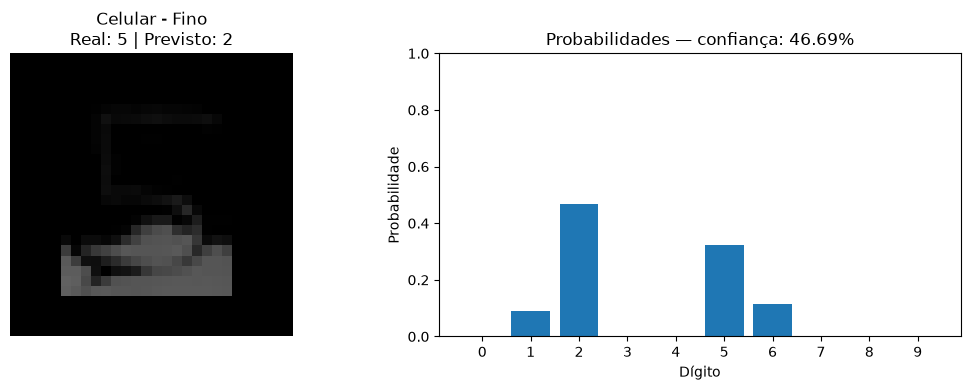

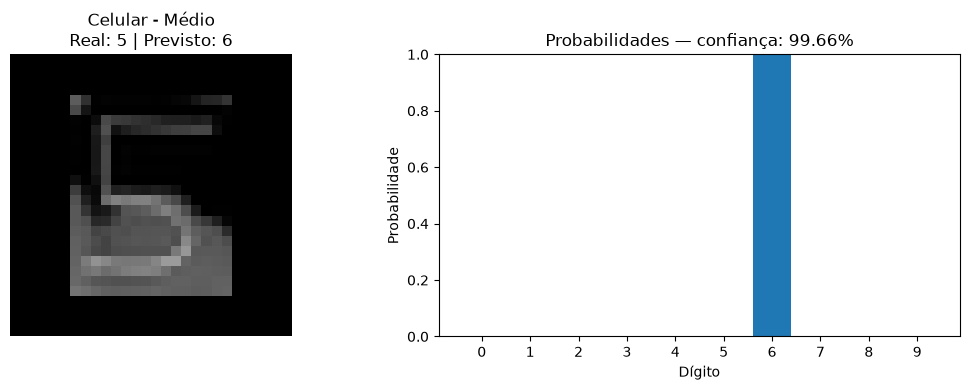

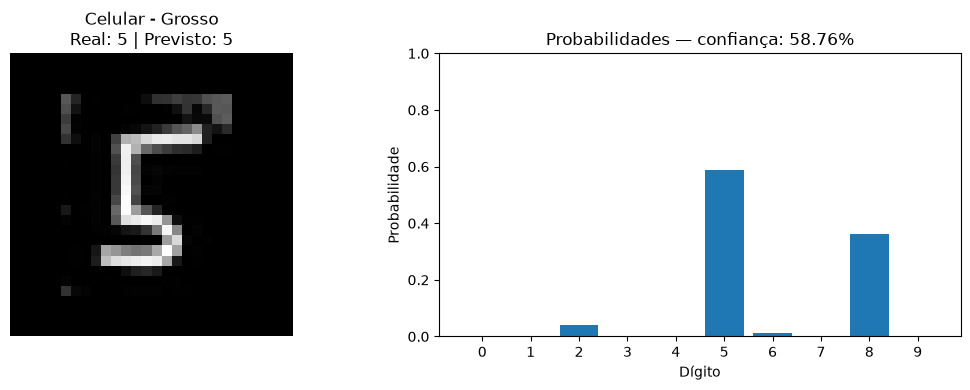

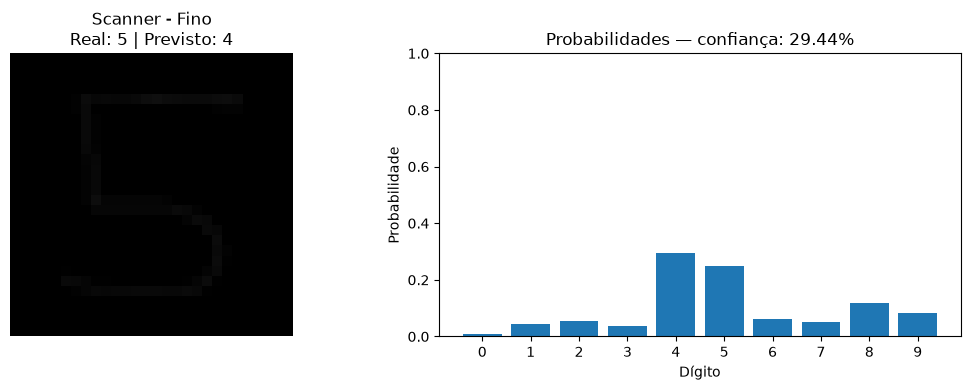

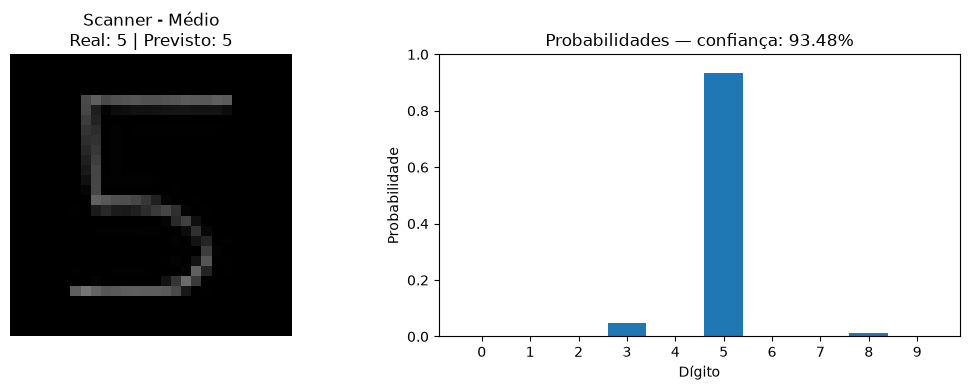

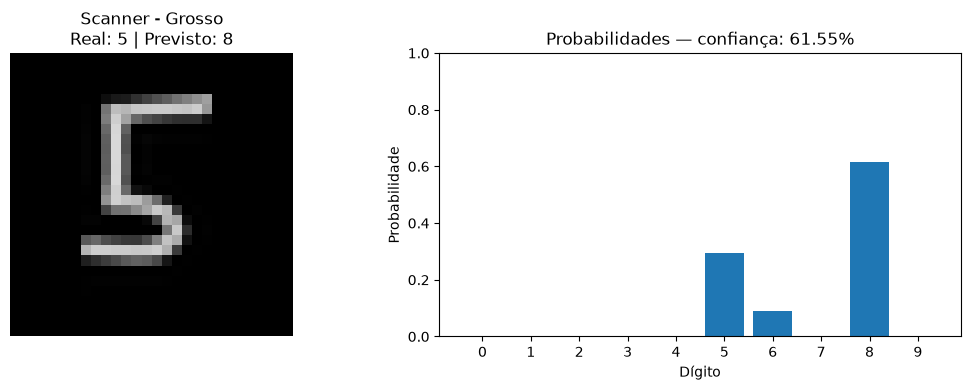

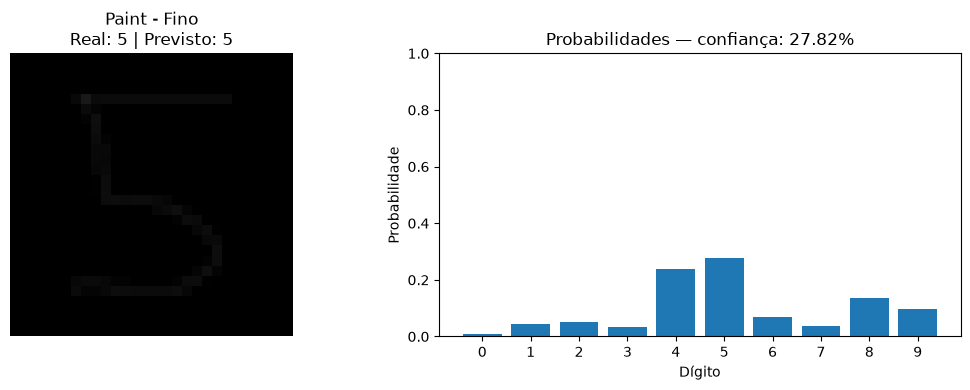

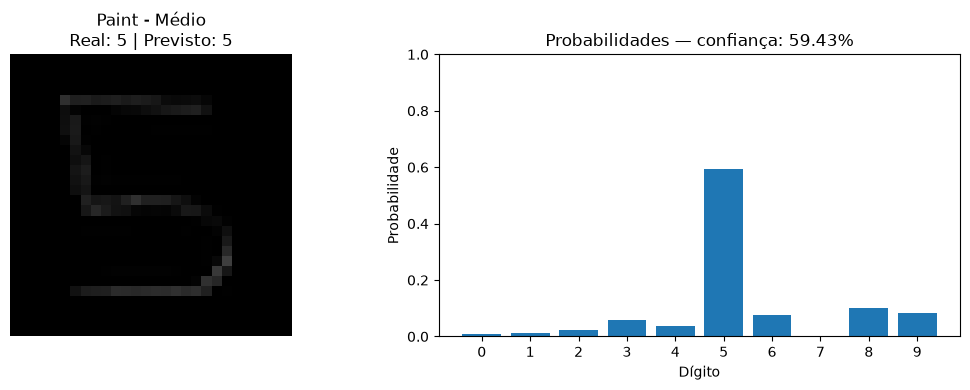

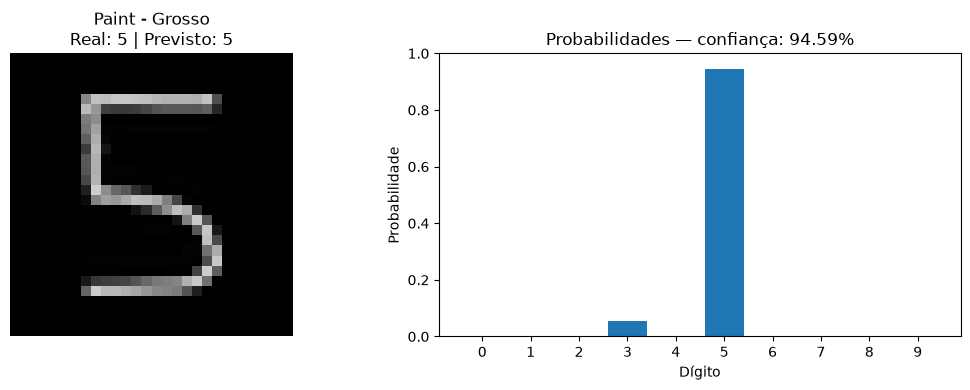

In [260]:
for nome, dados in imagens_teste.items():

    caminho = dados["caminho"]
    inverter = dados["inverter"]

    imagem_processada = preprocessar_imagem(
        caminho,
        inverter=inverter,
        limiar=80
    )

    entrada = imagem_processada.reshape(
        1,
        -1
    )

    predicao = int(
        mlp_final.predict(entrada)[0]
    )

    probabilidades = mlp_final.predict_proba(
        entrada
    )[0]

    confianca = probabilidades.max()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4)
    )

    # Imagem processada
    axes[0].imshow(
        imagem_processada,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[0].set_title(
        f"{nome}\n"
        f"Real: 5 | Previsto: {predicao}"
    )

    axes[0].axis("off")

    # Probabilidades
    axes[1].bar(
        range(10),
        probabilidades
    )

    axes[1].set_title(
        f"Probabilidades — confiança: {confianca:.2%}"
    )

    axes[1].set_xlabel(
        "Dígito"
    )

    axes[1].set_ylabel(
        "Probabilidade"
    )

    axes[1].set_xticks(
        range(10)
    )

    axes[1].set_ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.show()

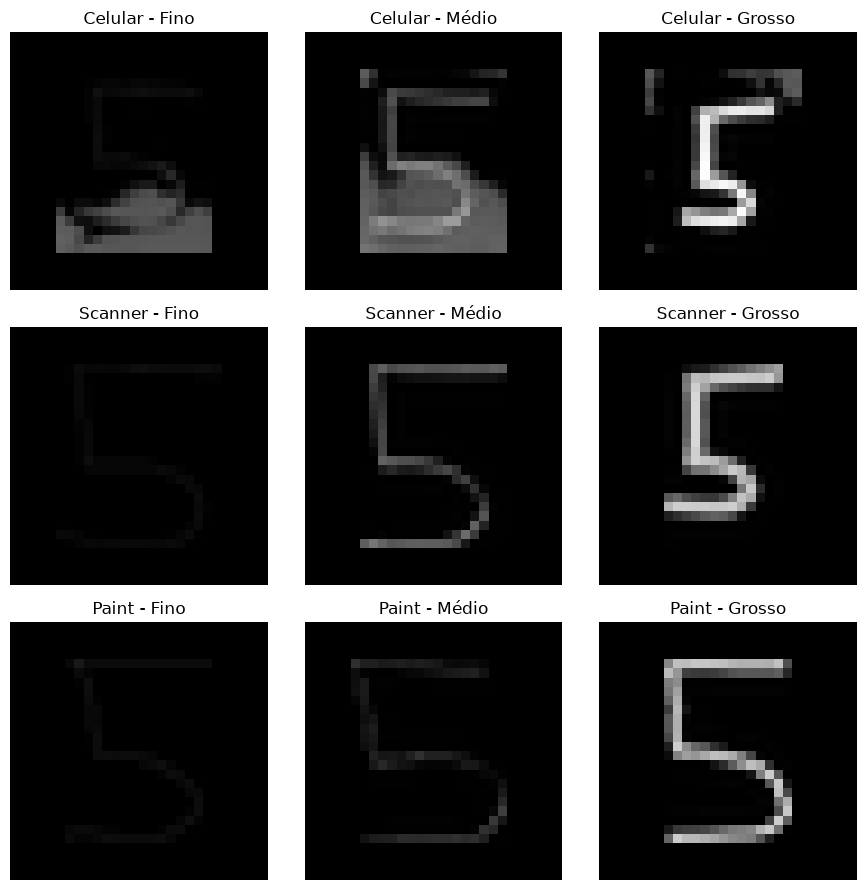

In [261]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(9, 9)
)

axes = axes.flatten()

for ax, (nome, dados) in zip(
    axes,
    imagens_teste.items()
):

    imagem_processada = preprocessar_imagem(
        dados["caminho"],
        inverter=dados["inverter"],
        limiar=80
    )

    ax.imshow(
        imagem_processada,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(nome)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [268]:
def preprocessar_imagem(caminho, inverter=True, limiar=80):

    imagem = Image.open(caminho)

    # Escala de cinza
    imagem = imagem.convert("L")

    # Inverte apenas celular e scanner
    if inverter:
        imagem = ImageOps.invert(imagem)

    img_array = np.array(imagem)

    # Remove pixels fracos / ruído de fundo
    img_array = np.where(
        img_array >= limiar,
        img_array,
        0
    ).astype(np.uint8)

    imagem = Image.fromarray(img_array)

    # Bounding box
    mascara = img_array > 0
    coordenadas = np.argwhere(mascara)

    if coordenadas.size == 0:
        raise ValueError(
            f"Nenhum dígito detectado em {caminho}"
        )

    y_min, x_min = coordenadas.min(axis=0)
    y_max, x_max = coordenadas.max(axis=0)

    imagem = imagem.crop(
        (x_min, y_min, x_max + 1, y_max + 1)
    )

    # Redimensionamento
    imagem.thumbnail(
        (20, 20),
        Image.Resampling.LANCZOS
    )

    # Canvas MNIST 28x28
    canvas = Image.new(
        "L",
        (28, 28),
        0
    )

    # Centralização
    x = (28 - imagem.width) // 2
    y = (28 - imagem.height) // 2

    canvas.paste(imagem, (x, y))

    # NÃO dividir por 255 aqui.
    # mlp_final já possui normalização.
    return np.array(
        canvas,
        dtype=np.float32
    )

In [269]:
resultados_5_3 = []

for nome, dados in imagens_teste.items():

    imagem_processada = preprocessar_imagem(
        dados["caminho"],
        inverter=dados["inverter"]
    )

    entrada = imagem_processada.reshape(1, -1)

    predicao = int(
        mlp_final.predict(entrada)[0]
    )

    probabilidades = mlp_final.predict_proba(
        entrada
    )[0]

    confianca = float(probabilidades.max())

    resultado = (
        "Correto"
        if predicao == 5
        else "Incorreto"
    )

    resultados_5_3.append({
        "Imagem": nome,
        "Real": 5,
        "Previsto": predicao,
        "Confiança (%)": round(confianca * 100, 2),
        "Resultado": resultado
    })

    print(
        f"{nome}: "
        f"real = 5 | "
        f"previsto = {predicao} | "
        f"confiança = {confianca:.2%} | "
        f"{resultado}"
    )

Celular - Fino: real = 5 | previsto = 2 | confiança = 46.69% | Incorreto
Celular - Médio: real = 5 | previsto = 6 | confiança = 99.66% | Incorreto
Celular - Grosso: real = 5 | previsto = 5 | confiança = 58.76% | Correto
Scanner - Fino: real = 5 | previsto = 4 | confiança = 29.44% | Incorreto
Scanner - Médio: real = 5 | previsto = 5 | confiança = 93.48% | Correto
Scanner - Grosso: real = 5 | previsto = 8 | confiança = 61.55% | Incorreto
Paint - Fino: real = 5 | previsto = 5 | confiança = 27.82% | Correto
Paint - Médio: real = 5 | previsto = 5 | confiança = 59.43% | Correto
Paint - Grosso: real = 5 | previsto = 5 | confiança = 94.59% | Correto


In [270]:
df_resultados_5_3 = pd.DataFrame(resultados_5_3)

df_resultados_5_3

,Imagem,Real,Previsto,Confiança (%),Resultado
0,Celular - Fino,5,2,46.69,Incorreto
1,Celular - Médio,5,6,99.66,Incorreto
2,Celular - Grosso,5,5,58.76,Correto
3,Scanner - Fino,5,4,29.44,Incorreto
4,Scanner - Médio,5,5,93.48,Correto
5,Scanner - Grosso,5,8,61.55,Incorreto
6,Paint - Fino,5,5,27.82,Correto
7,Paint - Médio,5,5,59.43,Correto
8,Paint - Grosso,5,5,94.59,Correto


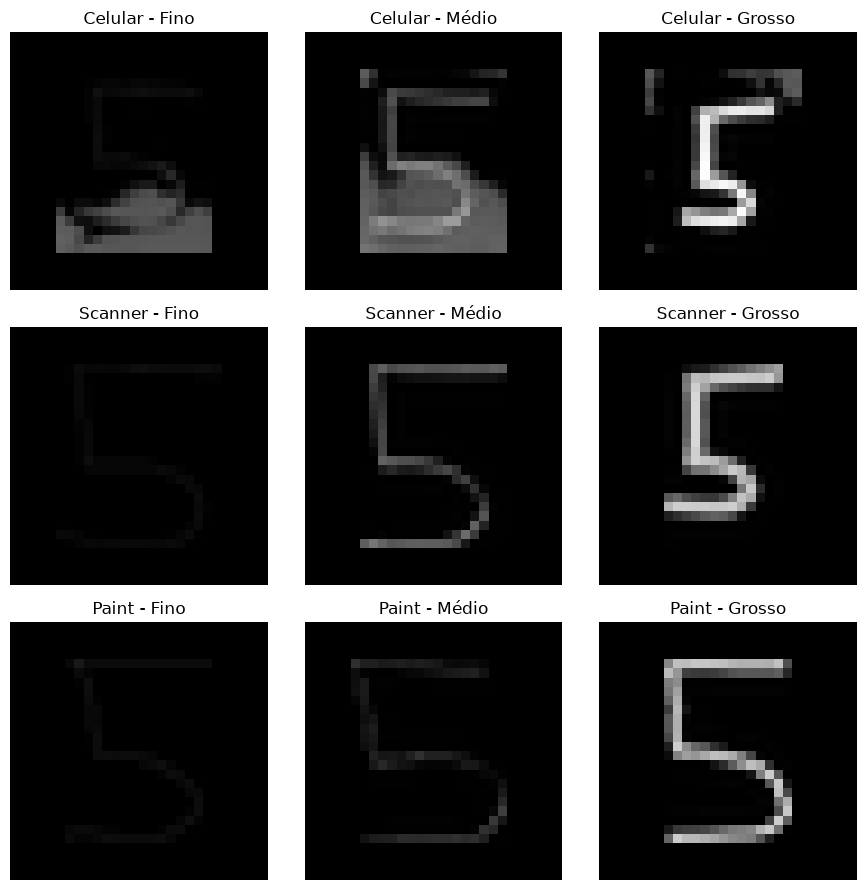

In [271]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(9, 9)
)

axes = axes.flatten()

for ax, (nome, dados) in zip(
    axes,
    imagens_teste.items()
):

    imagem_processada = preprocessar_imagem(
        dados["caminho"],
        inverter=dados["inverter"]
    )

    ax.imshow(
        imagem_processada,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(nome)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [273]:
plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "comparacao_imagens_processadas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

### Análise visual das imagens após o pré-processamento

A figura apresenta as nove imagens após o pipeline de pré-processamento
e permite observar diferenças importantes entre os métodos de aquisição
e as diferentes espessuras de traço.

As imagens foram convertidas para uma representação de **28 × 28 pixels**,
com fundo escuro e dígito claro, buscando aproximar as amostras externas
do padrão utilizado pelo conjunto MNIST.

Nas imagens obtidas pelo **celular**, observa-se maior presença de
variações de intensidade e resíduos de fundo, especialmente nas imagens
com traços fino e médio. Esses artefatos são decorrentes das condições
de aquisição, como iluminação, sombras, contraste e características da
fotografia, e permanecem parcialmente presentes mesmo após o
pré-processamento.

Nas imagens provenientes do **scanner**, o fundo apresentou maior
uniformidade. Entretanto, a espessura do traço modificou
consideravelmente a representação final do dígito. O traço fino ficou
pouco intenso, enquanto os traços médio e grosso produziram
representações mais definidas.

As imagens produzidas no **Paint** apresentaram fundo mais uniforme e
menor quantidade de ruído. Também é possível observar claramente o
aumento da intensidade e espessura do dígito entre as versões fina,
média e grossa.

Essa comparação demonstra que imagens representando o mesmo dígito
podem resultar em matrizes de pixels significativamente diferentes após
o pré-processamento. Como a rede neural realiza suas previsões a partir
desses valores de pixels, alterações de contraste, intensidade,
espessura e ruído podem modificar tanto a classe prevista quanto a
confiança da classificação.

Esse comportamento ajuda a explicar a diferença entre o elevado
desempenho obtido no conjunto MNIST e os resultados observados nas
imagens externas.

# Conclusão Geral do Projeto

Este projeto teve como objetivo desenvolver e avaliar modelos de
aprendizado de máquina capazes de realizar a **classificação de dígitos
manuscritos utilizando o conjunto de dados MNIST**, percorrendo as
principais etapas de um projeto de Machine Learning: análise exploratória,
pré-processamento, treinamento, seleção de hiperparâmetros, avaliação e
testes com dados externos.

O conjunto MNIST utilizado possui **70.000 imagens de dígitos de 0 a 9**,
representadas originalmente por matrizes de 28 × 28 pixels. Para utilização
pelos modelos, cada imagem foi representada por um vetor contendo
**784 atributos**, correspondentes às intensidades de seus pixels.

Durante o pré-processamento, os valores dos pixels, originalmente no
intervalo de 0 a 255, foram normalizados para o intervalo `[0,1]`.
Também foram definidos conjuntos distintos para treinamento, validação
e teste, permitindo realizar a seleção dos modelos sem utilizar o
conjunto de teste durante o processo de escolha dos hiperparâmetros.

## Comparação dos modelos

Foram avaliados três algoritmos de classificação:

- **K-Nearest Neighbors (KNN)**;
- **Random Forest**;
- **Multilayer Perceptron (MLP)**.

Após a busca e comparação das diferentes configurações, os melhores
hiperparâmetros encontrados foram utilizados para o treinamento final
dos modelos.

No conjunto de teste, foram obtidos os seguintes resultados:

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| MLP | 98,01% | 98,01% | 98,01% | 98,01% |
| KNN | 97,32% | 97,34% | 97,32% | 97,32% |
| Random Forest | 96,78% | 96,78% | 96,78% | 96,78% |

A **MLP apresentou o melhor desempenho geral**, alcançando aproximadamente
**98,01% de acurácia no conjunto de teste**, além dos melhores valores de
Precision, Recall e F1 entre os três modelos avaliados.

A análise dos tempos computacionais mostrou características diferentes
entre os algoritmos. O KNN apresentou treinamento extremamente rápido,
mas maior tempo de inferência, comportamento esperado por se tratar de
um algoritmo baseado na comparação com as amostras armazenadas. A Random
Forest apresentou comportamento intermediário, enquanto a MLP exigiu
maior tempo de treinamento, porém apresentou inferência rápida após o
modelo estar treinado.

Dessa forma, considerando conjuntamente **desempenho preditivo e tempo
de inferência**, a MLP foi selecionada como modelo final do projeto.

## Análise dos erros

As matrizes de confusão mostraram forte concentração de valores na
diagonal principal nos três modelos, indicando elevado número de
classificações corretas.

Entretanto, também foram identificadas confusões entre determinados
dígitos visualmente semelhantes. No modelo final MLP, por exemplo,
ocorreram erros entre classes com características gráficas próximas,
demonstrando que pequenas variações na escrita podem alterar a decisão
do classificador.

Essa análise mostrou que métricas globais, como acurácia, não devem ser
avaliadas isoladamente. A matriz de confusão permite compreender quais
classes apresentam maior dificuldade para o modelo e quais tipos de
erros estão sendo cometidos.

## Classes ocultas e dados fora da distribuição

O projeto também avaliou o comportamento do modelo diante de classes
ocultas durante o treinamento.

Esse experimento demonstrou que um classificador pode produzir uma
resposta mesmo quando recebe uma entrada pertencente a uma situação
diferente daquela considerada durante seu treinamento. Além disso, foram
observados casos em que o modelo apresentou elevada confiança mesmo
quando sua decisão não deveria ser interpretada como confiável.

Esse comportamento está relacionado ao problema de **overconfidence
(falsa certeza)** em modelos de Inteligência Artificial e evidencia que
uma elevada probabilidade de saída não representa necessariamente
garantia de que a decisão esteja correta.

## Inferência com imagens próprias

Para avaliar a capacidade de generalização do modelo em condições mais
próximas de uma aplicação real, também foram utilizadas imagens externas
do dígito **5**.

O experimento foi ampliado para nove imagens, combinando três métodos
de aquisição:

- fotografia realizada com celular;
- digitalização por scanner a 300 dpi;
- desenho digital produzido no Paint;

com três espessuras de traço:

- fino;
- médio;
- grosso.

As imagens foram submetidas a um pipeline específico de pré-processamento,
incluindo conversão para escala de cinza, inversão quando necessária,
remoção de parte do ruído de fundo, identificação da região do dígito,
redimensionamento e centralização em 28 × 28 pixels.

Das nove imagens externas avaliadas, **5 foram corretamente classificadas**,
correspondendo a **55,56% de acerto neste pequeno experimento**.

As três imagens produzidas no Paint foram corretamente reconhecidas.
Nas imagens obtidas pelo celular, apenas uma das três foi corretamente
classificada, resultado também observado nas imagens provenientes do
scanner.

Um resultado particularmente relevante ocorreu na imagem
**Celular - Médio**: embora o dígito verdadeiro fosse 5, o modelo realizou
a previsão como **6 com 99,66% de confiança**.

Esse resultado constitui uma demonstração prática de **overconfidence**:
o modelo apresentou uma confiança extremamente elevada em uma decisão
incorreta.

Também foi possível observar que diferenças aparentemente simples na
forma de aquisição, intensidade e espessura dos traços produziram
representações 28 × 28 significativamente diferentes após o
pré-processamento, influenciando diretamente as previsões realizadas
pela rede neural.

## Considerações finais

Os resultados demonstraram que a MLP apresentou excelente desempenho
quando avaliada em dados do próprio MNIST, alcançando aproximadamente
**98% de acurácia**, e foi o melhor dos três algoritmos avaliados.

Entretanto, os experimentos adicionais mostraram uma conclusão igualmente
importante: **um elevado desempenho no conjunto de teste não significa
que o modelo terá necessariamente o mesmo desempenho diante de dados
obtidos em condições diferentes das utilizadas em seu desenvolvimento**.

As diferenças observadas nas imagens externas evidenciam a importância
da distribuição dos dados, da qualidade das entradas e principalmente
da consistência do pré-processamento. Também demonstram que a confiança
informada pelo classificador deve ser interpretada com cautela, pois o
modelo pode apresentar elevada certeza mesmo quando sua previsão está
incorreta.

Assim, além de permitir a implementação e comparação de diferentes
algoritmos de classificação, o projeto demonstrou na prática conceitos
fundamentais de Machine Learning, como **generalização, seleção de
modelos, avaliação por múltiplas métricas, análise de erros, dados fora
da distribuição e overconfidence**.

Como possibilidade de evolução do projeto, poderiam ser avaliadas
técnicas de **data augmentation**, métodos mais robustos de
pré-processamento e centralização, calibração das probabilidades e
arquiteturas específicas para processamento de imagens, como
**Redes Neurais Convolucionais (CNNs)**. Também seria interessante
ampliar o experimento externo para um número maior de imagens e para
todos os dígitos de 0 a 9.

De forma geral, o projeto atingiu seu objetivo de desenvolver,
comparar e avaliar classificadores para o MNIST e, principalmente,
demonstrou que a avaliação de um sistema de Inteligência Artificial
não deve se limitar apenas à obtenção de uma alta acurácia, mas também
deve considerar **como o modelo se comporta diante de situações
diferentes daquelas observadas durante o treinamento**.